In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import pprint

In [2]:
# open csv file
df = pd.read_csv("../data/cleaned/town_level_merged_for_eda.csv")

# open geojson file
gdf = gpd.read_file("../data/cleaned/census.geojson")

#### Clean data and functions for building index and model evaluation

In [3]:
# clean up missing values - fill funding and claims NaNs with 0,
# drop towns with zero population, and display remaining NaNs in ACS columns

# columns to check for NaNs
cols_to_check = [
    # "pct_river_corridor",
    # "pct_high_risk_NFHL",
    "median_income",
    "percent_elderly",
    "median_year_house_built",
    "pct_no_vehicle",
    "pct_renter_occupied",
    "pct_bachelors_or_higher",
    "pct_below_poverty",
    "percent_with_disability",
    "pct_mobile_home",
    # "funding_per_capita",
    # "log_funding_per_capita",
    # "funding_per_occupied_unit",
    # "log_funding_per_occupied_unit",
    # "claims_paid_per_capita",
    # "current_insurance_penetration",
]
# # print statement commented out, but left in case of testing (as with above columns)
# print("Missing values in key columns:")
# for col in cols_to_check:
#     missing = df[col].isna().sum()
#     print(f"{col}: {missing} missing values")

# fill funding and claims NaNs with 0
cols_to_fill = [
    "funding_per_capita",
    "log_funding_per_capita",
    "funding_per_occupied_unit",
    "log_funding_per_occupied_unit",
    "claims_paid_per_capita",
    "current_insurance_penetration",
]
df[cols_to_fill] = df[cols_to_fill].fillna(0)

# drop towns with zero population
print(f"\nTowns before filtering for zero population: {len(df)}")
df = df[df["total_population"] > 0]
print(f"Towns after filtering for zero population: {len(df)}\n")

# display remaining NaNs in ACS columns
print("Missing values in key columns:")
print("(problematic for modeling)")
for col in cols_to_check:
    missing = df[col].isna().sum()
    print(f"{col}: {missing} missing values")

# print correlation matrix for key variables to check for multicollinearity
df[cols_to_check].corr().round(2)


Towns before filtering for zero population: 256
Towns after filtering for zero population: 250

Missing values in key columns:
(problematic for modeling)
median_income: 3 missing values
percent_elderly: 0 missing values
median_year_house_built: 6 missing values
pct_no_vehicle: 0 missing values
pct_renter_occupied: 0 missing values
pct_bachelors_or_higher: 0 missing values
pct_below_poverty: 0 missing values
percent_with_disability: 0 missing values
pct_mobile_home: 0 missing values


,median_income,percent_elderly,median_year_house_built,pct_no_vehicle,pct_renter_occupied,pct_bachelors_or_higher,pct_below_poverty,percent_with_disability,pct_mobile_home
median_income,1.00,-0.07,0.23,-0.32,-0.17,0.57,-0.49,-0.43,-0.28
percent_elderly,-0.07,1.00,-0.15,-0.07,-0.21,0.09,0.03,0.12,-0.15
median_year_house_built,0.23,-0.15,1.00,-0.33,-0.32,0.08,-0.09,-0.24,0.21
pct_no_vehicle,-0.32,-0.07,-0.33,1.00,0.61,-0.05,0.17,0.31,-0.09
pct_renter_occupied,-0.17,-0.21,-0.32,0.61,1.00,0.07,0.17,0.14,-0.14
pct_bachelors_or_higher,0.57,0.09,0.08,-0.05,0.07,1.00,-0.35,-0.41,-0.49
pct_below_poverty,-0.49,0.03,-0.09,0.17,0.17,-0.35,1.00,0.11,0.21
percent_with_disability,-0.43,0.12,-0.24,0.31,0.14,-0.41,0.11,1.00,0.21
pct_mobile_home,-0.28,-0.15,0.21,-0.09,-0.14,-0.49,0.21,0.21,1.00


In [4]:
# flag towns that received any funding (for modeling purposes later on)
df["received_funding"] = (df["funding_per_capita"] > 0).astype(int)
df["received_funding"].value_counts()

received_funding
0    130
1    120
Name: count, dtype: int64

In [ ]:
def preprocess(df, log_transform=None):
    df = df.copy()

    # replace inf values with NaN to avoid issues in modeling
    # df = df.replace([np.inf, -np.inf], np.nan)

    # optional log transformation
    if log_transform:
        for col in log_transform:
            # safeguard against accidentally double-log-transforming variables
            if not col.startswith("log_"):
                df[col] = np.log1p(df[col])

    return df


def z_normalize(df, cols):
    df = df.copy()
    scaler = StandardScaler()
    df[cols] = scaler.fit_transform(df[cols])
    return df


def rank_normalize(df, cols):
    df = df.copy()
    for col in cols:
        df[col] = df[col].rank(pct=True)
    return df


def build_index(df, risk_vars, vuln_vars, funding_var, method="z", log_funding=False):
    df = df.copy()

    all_vars = risk_vars + vuln_vars

    # normalize risk and vulnerability variables using specified method
    if all_vars:
        df_norm = (
            z_normalize(df, all_vars) if method == "z" else rank_normalize(df, all_vars)
        )
    else:
        df_norm = df.copy()

    # calculate risk and vulnerability indices as the mean of their respective (z-scored) variables
    df["risk_index"] = df_norm[risk_vars].mean(axis=1) if risk_vars else 0
    df["vuln_index"] = df_norm[vuln_vars].mean(axis=1) if vuln_vars else 0

    # combined need index (normalized 0–1-ish if rank, centered if z)
    df["need_index"] = (df["risk_index"] + df["vuln_index"]) / 2

    # # prepare funding series (optional log to reduce skew)
    # # safeguard - I've already log-transformed funding and filled NaNs in preprocessing
    funding = df[funding_var].fillna(0).copy()
    if log_funding:
        funding = np.log1p(funding)

    # scale funding to match chosen normalization method
    if method == "rank":
        # percentile ranks in ~[0,1] to match rank-based indices
        df["funding_scaled"] = funding.rank(pct=True)
    else:
        # z-score to match z-normalized indices (centered around 0)
        df["funding_scaled"] = (
            StandardScaler().fit_transform(funding.values.reshape(-1, 1)).ravel()
        )

    # gap: positive => overfunded relative to need; negative => underfunded
    df["gap_index"] = df["funding_scaled"] - df["need_index"]

    return df


def run_logit(df, X_vars):
    # add constant for intercept
    X = sm.add_constant(df[X_vars])
    y = df["received_funding"]

    # fit logistic regression model
    model = sm.Logit(y, X).fit(disp=0)  # disp=0 to suppress printing convergence output

    # save predicted probabilities back to dataframe
    df = df.copy()
    df["pred_logit"] = model.predict(X)

    return df, model


def run_ols(df, X_vars, y_var):
    # restrict to rows that received funding for OLS modeling
    df = df[df["received_funding"] == 1].copy()

    # add constant for intercept
    X = sm.add_constant(df[X_vars])
    y = df[y_var]

    # fit OLS model
    model = sm.OLS(y, X).fit()

    # save predictions and residuals back to dataframe
    # positive residual means overfunded relative to model prediction, negative residual means underfunded
    df["predicted"] = model.predict(X)
    df["residual"] = df[y_var] - df["predicted"]

    return df, model

In [ ]:
def compare_indices(df_z, df_rank):
    merged = df_z[["GEOID", "town_name", "need_index"]].merge(
        df_rank[["GEOID", "need_index"]], on="GEOID", suffixes=("_z", "_rank")
    )

    spearman_corr, _ = spearmanr(merged["need_index_z"], merged["need_index_rank"])

    merged["rank_z"] = merged["need_index_z"].rank()
    merged["rank_rank"] = merged["need_index_rank"].rank()
    merged["rank_diff"] = merged["rank_z"] - merged["rank_rank"]

    print(f"\nIndex Spearman correlation (z vs rank): {spearman_corr:.3f}")

    return merged


def get_index_extremes(df, n=10):
    return {
        "highest_need": df.nlargest(n, "need_index")[["town_name", "need_index"]],
        "lowest_need": df.nsmallest(n, "need_index")[["town_name", "need_index"]],
    }


def summarize_model(name, df_logit, compare_df, df_ols, ols_model):
    # index comparison stats
    try:
        spearman_corr = spearmanr(
            compare_df["need_index_z"], compare_df["need_index_rank"]
        )[0]
    except Exception:
        spearman_corr = np.nan

    mean_rank_diff = (
        compare_df["rank_diff"].abs().mean()
        if "rank_diff" in compare_df.columns
        else np.nan
    )
    max_rank_diff = (
        compare_df["rank_diff"].abs().max()
        if "rank_diff" in compare_df.columns
        else np.nan
    )

    pct_large_diff = (
        (compare_df["rank_diff"].abs() > 50).mean()
        if "rank_diff" in compare_df.columns
        else np.nan
    )

    ols_n = len(df_ols) if df_ols is not None else 0
    ols_r2 = getattr(ols_model, "rsquared", np.nan) if ols_model is not None else np.nan

    try:
        auc = roc_auc_score(df_logit["received_funding"], df_logit["pred_logit"])
    except Exception:
        auc = np.nan

    return {
        "model": name,
        "index_spearman_z_vs_rank": spearman_corr,
        "mean_rank_diff": mean_rank_diff,
        "max_rank_diff": max_rank_diff,
        "pct_rank_diff_gtr_50": pct_large_diff,
        "ols_n": ols_n,
        "ols_r2": ols_r2,
        "logit_auc": auc,
    }


# def plot_choropleths(
#     df, gdf, value_cols=["gap_index", "residual"], geoid_col="GEOID", title_prefix="", suptitle=""
# ):
#     # ensure types are correct for merging
#     df[geoid_col] = df[geoid_col].astype(str)
#     gdf[geoid_col] = gdf[geoid_col].astype(str)

#     # Merge result df with geodataframe on GEOID
#     plot_gdf = gdf.merge(df[[geoid_col] + value_cols], on=geoid_col, how="left")

#     fig, axes = plt.subplots(1, len(value_cols), figsize=(7 * len(value_cols), 8))
#     if len(value_cols) == 1:
#         axes = [axes]

#     for ax, col in zip(axes, value_cols):
#         plot_gdf.plot(
#             column=col,
#             cmap="coolwarm",
#             # set vmin and vmax to be symmetric around zero, to ensure consistent coloring of over- vs underfunded areas
#             vmin=-abs(plot_gdf[col]).max(),
#             vmax=abs(plot_gdf[col]).max(),
#             linewidth=0.2,
#             edgecolor="gray",
#             legend=True,
#             ax=ax,
#             missing_kwds={"color": "lightgrey", "label": "Missing"},
#         )
#         ax.set_title(f"{title_prefix}{col}")
#         ax.axis("off")

#     if suptitle:
#         fig.suptitle(suptitle)

#     plt.tight_layout()
#     plt.show()

In [ ]:
def plot_basic(df, suptitle=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # gap_index vs residual
    axes[0].scatter(df["need_index_z"], df["need_index_rank"])
    axes[0].set_xlabel("Z Index")
    axes[0].set_ylabel("Rank Index")
    axes[0].set_title("Z Index vs Rank Index")

    # predicted vs residual
    axes[1].hist(df["rank_diff"], bins=30)
    axes[1].set_title("Rank Difference (Z vs Rank)")

    if suptitle:
        fig.suptitle(suptitle)

    plt.tight_layout()
    plt.show()

    plt.scatter(df["need_index_rank"], df["rank_diff"])
    plt.xlabel("Need Index (Rank)")
    plt.ylabel("Rank Difference (Z - Rank)")
    plt.axhline(0, linestyle="--")
    plt.title("Rank Instability vs Need")
    plt.show()


def plot_two_choropleths(
    df_left,
    df_right,
    gdf,
    col="need_index",
    geoid_col="GEOID",
    titles=("Left", "Right"),
    suptitle="",
    cmap="coolwarm",
    figsize=(14, 8),
):
    """Plot two choropleths side-by-side with a shared symmetric color scale."""

    # helper to ensure requested column exists and GEOID is string
    def _prep(df):
        if col in df.columns:
            out = df[[geoid_col, col]].copy()
        else:
            out = df[[geoid_col]].copy()
            out[col] = np.nan
        out[geoid_col] = out[geoid_col].astype(str)
        return out

    # prepare both dataframes and the geodataframe for merging
    left = _prep(df_left)
    right = _prep(df_right)
    g = gdf.copy()
    g[geoid_col] = g[geoid_col].astype(str)

    # merge with geodataframe
    mleft = g.merge(left, on=geoid_col, how="left")
    mright = g.merge(right, on=geoid_col, how="left")

    # determine vmin and vmax for symmetric color scale based on combined data
    vals = pd.concat([mleft[col], mright[col]])
    vals = pd.to_numeric(vals, errors="coerce")
    if vals.notna().any():
        max_abs = float(np.nanmax(np.abs(vals)))
        vmin, vmax = -max_abs, max_abs
    else:
        vmin = vmax = None

    # plot side-by-side choropleths with shared color scale
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, mg, title in zip(axes, (mleft, mright), titles):
        mg.plot(
            column=col,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            linewidth=0.2,
            edgecolor="gray",
            legend=True,
            ax=ax,
            missing_kwds={"color": "lightgrey", "label": "Missing"},
        )
        ax.set_title(title)
        ax.axis("off")

    # add suptitle if provided
    if suptitle:
        fig.suptitle(suptitle)

    plt.tight_layout()
    plt.show()

In [8]:
def run_model_suite(df, gdf, model_specs):
    all_results = {}
    summary_rows = []

    for name, spec in model_specs.items():
        print(f"\n=== {name} ===")

        # extract spec components
        risk_vars = spec.get("risk", [])
        vuln_vars = spec.get("vuln", [])
        # spec components with defaults
        funding_var = spec.get("funding_var", "log_funding_per_capita")
        log_transform = spec.get("log_transform", None)

        # define X variables
        X_vars = risk_vars + vuln_vars

        # preprocess
        df_proc = preprocess(df, log_transform)

        # build both indices
        df_z = build_index(df_proc, risk_vars, vuln_vars, funding_var, method="z")
        df_rank = build_index(df_proc, risk_vars, vuln_vars, funding_var, method="rank")

        # compare
        compare_df = compare_indices(df_z, df_rank)

        # models (run on z version only for consistency)
        df_logit, logit_model = run_logit(df_z, X_vars)
        df_ols, ols_model = run_ols(df_logit, X_vars, funding_var)

        # store
        all_results[name] = {
            "z_index": df_z,
            "rank_index": df_rank,
            "comparison": compare_df,
            "logit_model": logit_model,
            "ols_model": ols_model,
        }

        # quick outputs
        display(get_index_extremes(df_rank, n=10))
        top_diff = compare_df.nlargest(20, "rank_diff")
        display(top_diff)

        # plots
        plot_basic(compare_df, suptitle=name)
        plot_two_choropleths(
            df_rank,
            df_z,
            gdf,
            col="need_index",
            titles=("Rank Index - need_index", "Z-Score Index - need_index"),
            suptitle=name,
        )

        # summarize
        summary_rows.append(
            summarize_model(name, df_logit, compare_df, df_ols, ols_model)
        )

    summary_df = pd.DataFrame(summary_rows).sort_values(
        by="index_spearman_z_vs_rank", ascending=False
    )

    print("\n=== SUMMARY ===")
    display(summary_df)
    return all_results, summary_df

# Define inputs and evalute index / models

In [9]:
model_specs = {
    "baseline_exposure": {"risk": ["pct_river_corridor"]},
    "baseline_vulnerability": {
        "vuln": ["pct_below_poverty", "percent_elderly", "pct_no_vehicle"],
        "log_transform": ["pct_below_poverty"],
    },
    "core_model": {
        "risk": ["pct_river_corridor"],
        "vuln": ["pct_below_poverty", "percent_elderly", "pct_no_vehicle"],
        "log_transform": ["pct_below_poverty"],
    },
    "expanded_model": {
        "risk": ["pct_river_corridor"],
        "vuln": [
            "pct_below_poverty",
            "percent_elderly",
            "pct_no_vehicle",
            "pct_renter_occupied",
            "pct_mobile_home",
        ],
        "log_transform": ["pct_below_poverty"],
    },
    "nfhl_model": {
        "risk": ["pct_high_risk_NFHL"],
        "vuln": ["pct_below_poverty", "percent_elderly"],
        "log_transform": ["pct_below_poverty"],
    },
    "claims_only": {"risk": ["claims_paid_per_capita"]},
    "combined": {
        "risk": ["pct_river_corridor"],
        "vuln": ["pct_below_poverty", "percent_elderly"],
        "log_transform": ["pct_below_poverty"],
    },
}


=== baseline_exposure_log_funding_per_capita ===

Index Spearman correlation (z vs rank): 1.000


{'highest_need':                town_name  need_index
 250        Winooski city       0.500
 68   Essex Junction city       0.498
 213       Vergennes city       0.496
 240       Weybridge town       0.494
 161         Proctor town       0.492
 174         Rutland city       0.490
 12            Barre city       0.488
 25          Brandon town       0.486
 132      Montpelier city       0.484
 37       Burlington city       0.482,
 'lowest_need':               town_name  need_index
 9        Baltimore town       0.006
 85      Grand Isle town       0.006
 104  Isle La Motte town       0.006
 144     North Hero town       0.006
 193     St. George town       0.006
 35           Buels gore       0.012
 189     South Hero town       0.014
 2          Alburgh town       0.016
 238       Westmore town       0.018
 110          Kirby town       0.020}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
0,5000100325,Addison town,-0.069905,0.274,137.0,137.0,0.0
1,5001900475,Albany town,0.026352,0.330,165.0,165.0,0.0
2,5001300860,Alburgh town,-0.654530,0.016,8.0,8.0,0.0
3,5002701300,Andover town,-0.325323,0.120,60.0,60.0,0.0
4,5000301450,Arlington town,0.192681,0.386,193.0,193.0,0.0
5,5002501900,Athens town,-0.325029,0.122,61.0,61.0,0.0
6,5000902125,Averill town,-0.504720,0.026,13.0,13.0,0.0
7,5001102500,Bakersfield town,-0.190319,0.192,96.0,96.0,0.0
8,5002702575,Baltimore town,-0.707679,0.006,3.0,3.0,0.0
9,5002702725,Barnard town,-0.347259,0.096,48.0,48.0,0.0


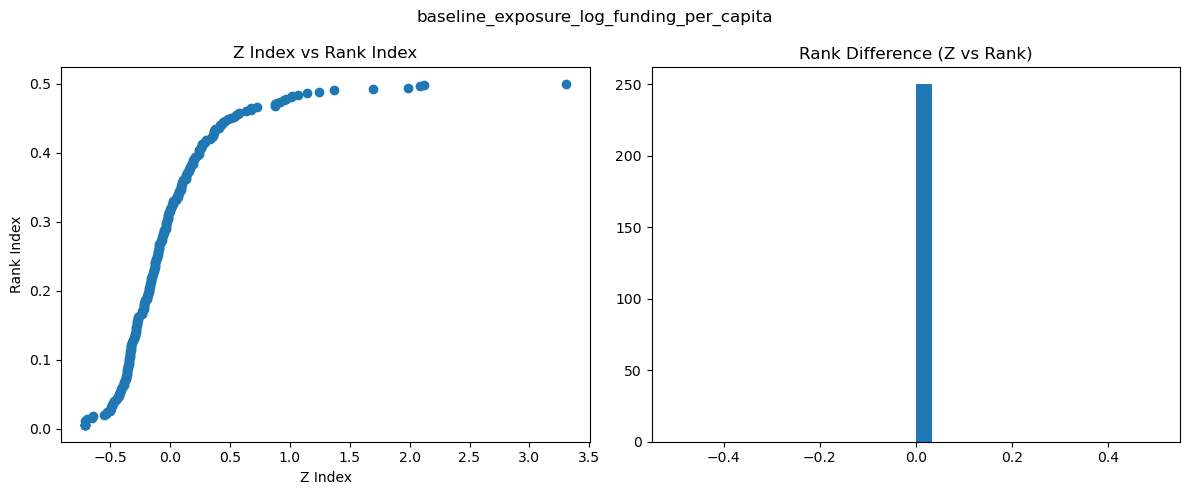

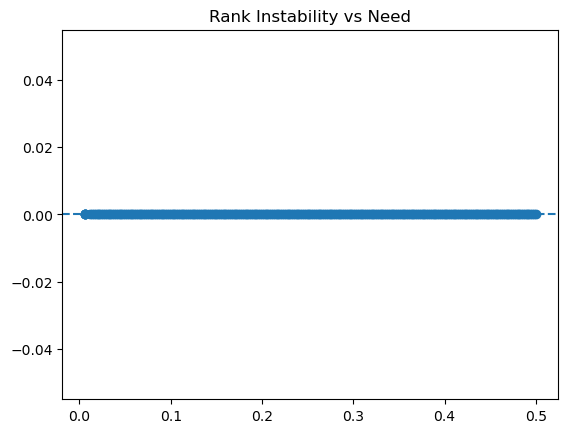

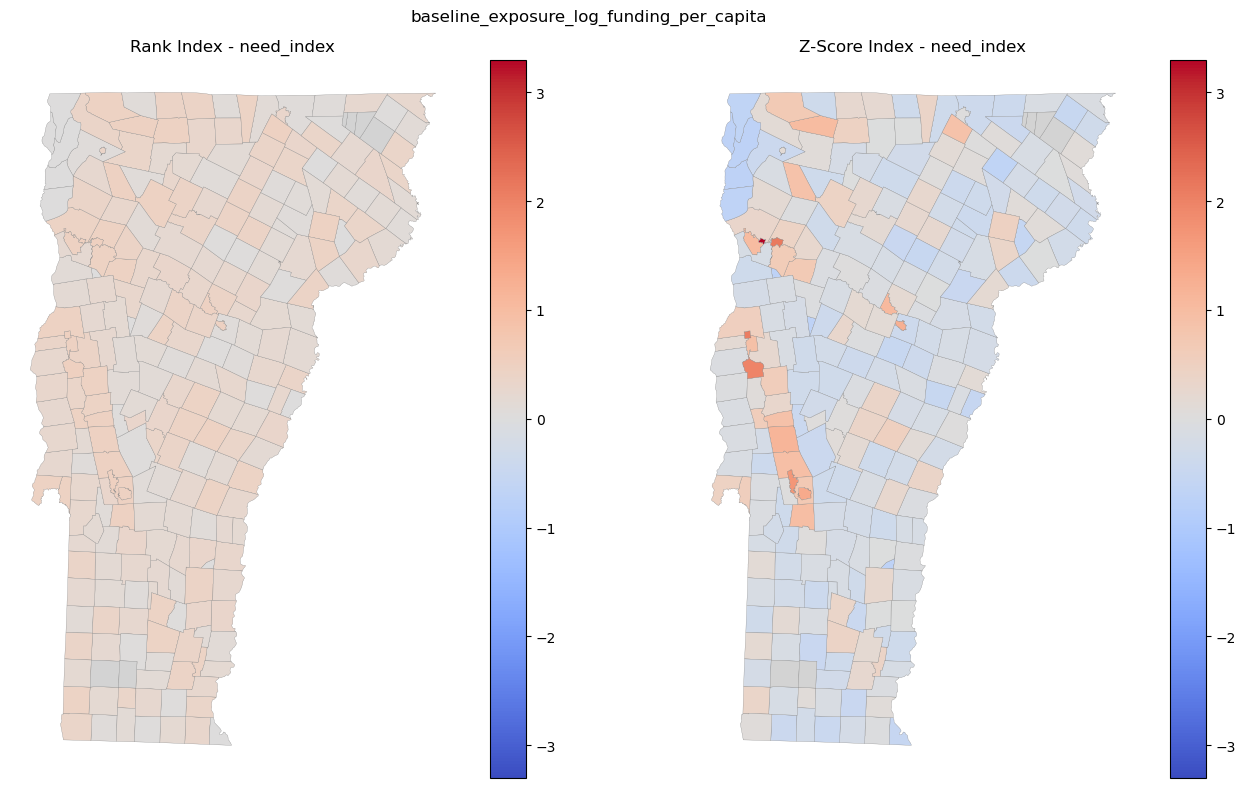


=== baseline_vulnerability_log_funding_per_capita ===

Index Spearman correlation (z vs rank): 0.958


{'highest_need':             town_name  need_index
 170   Rockingham town    0.460667
 29      Brighton town    0.442000
 142      Newport city    0.438667
 27   Bridgewater town    0.430667
 169    Rochester town    0.426667
 174      Rutland city    0.420000
 131   Montgomery town    0.417333
 26   Brattleboro town    0.416000
 73       Fairlee town    0.416000
 235    Westfield town    0.413333,
 'lowest_need':            town_name  need_index
 179   Searsburg town    0.012333
 201    Stratton town    0.016333
 9     Baltimore town    0.029333
 22       Bolton town    0.045333
 228  Waterville town    0.058000
 147     Norwich town    0.062667
 153        Peru town    0.076667
 65         Eden town    0.080000
 130     Monkton town    0.085333
 6       Averill town    0.087667}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
82,5000929125,Granby town,0.500635,0.250667,235.0,117.0,118.0
74,5000925975,Ferdinand town,0.456461,0.264667,233.0,131.0,102.0
216,5000176075,Waltham town,0.250834,0.244667,206.0,109.0,97.0
33,5000910075,Brunswick town,0.043310,0.206667,143.0,72.0,71.0
168,5002360625,Roxbury town,0.055390,0.222000,150.0,86.0,64.0
236,5000183800,Whiting town,0.474187,0.299333,234.0,170.5,63.5
34,5000710300,Buels gore,0.681316,0.314667,246.0,183.0,63.0
170,5000361000,Rupert town,0.279022,0.287333,212.0,156.0,56.0
244,5000785150,Winooski city,0.307388,0.303333,217.0,174.0,43.0
136,5000547725,Newark town,0.038037,0.234667,141.0,99.0,42.0


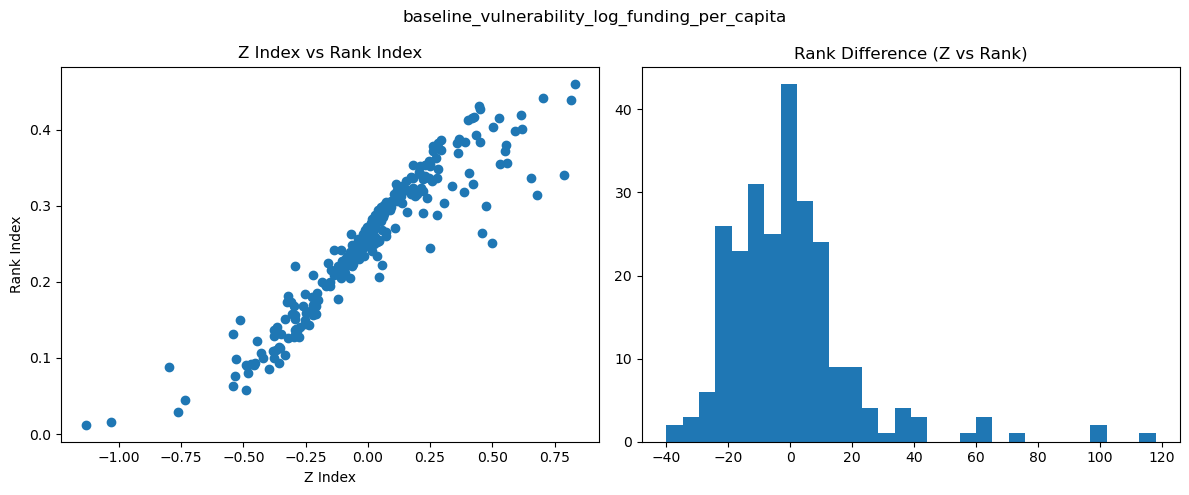

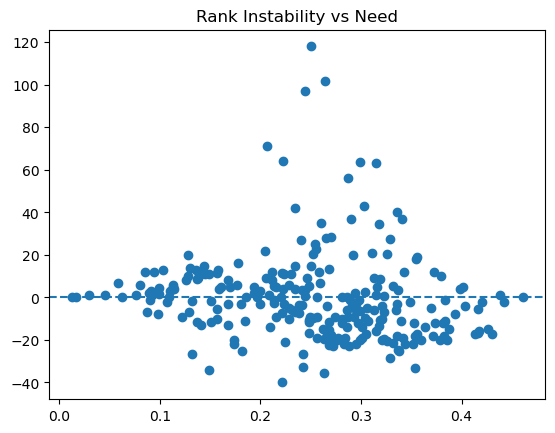

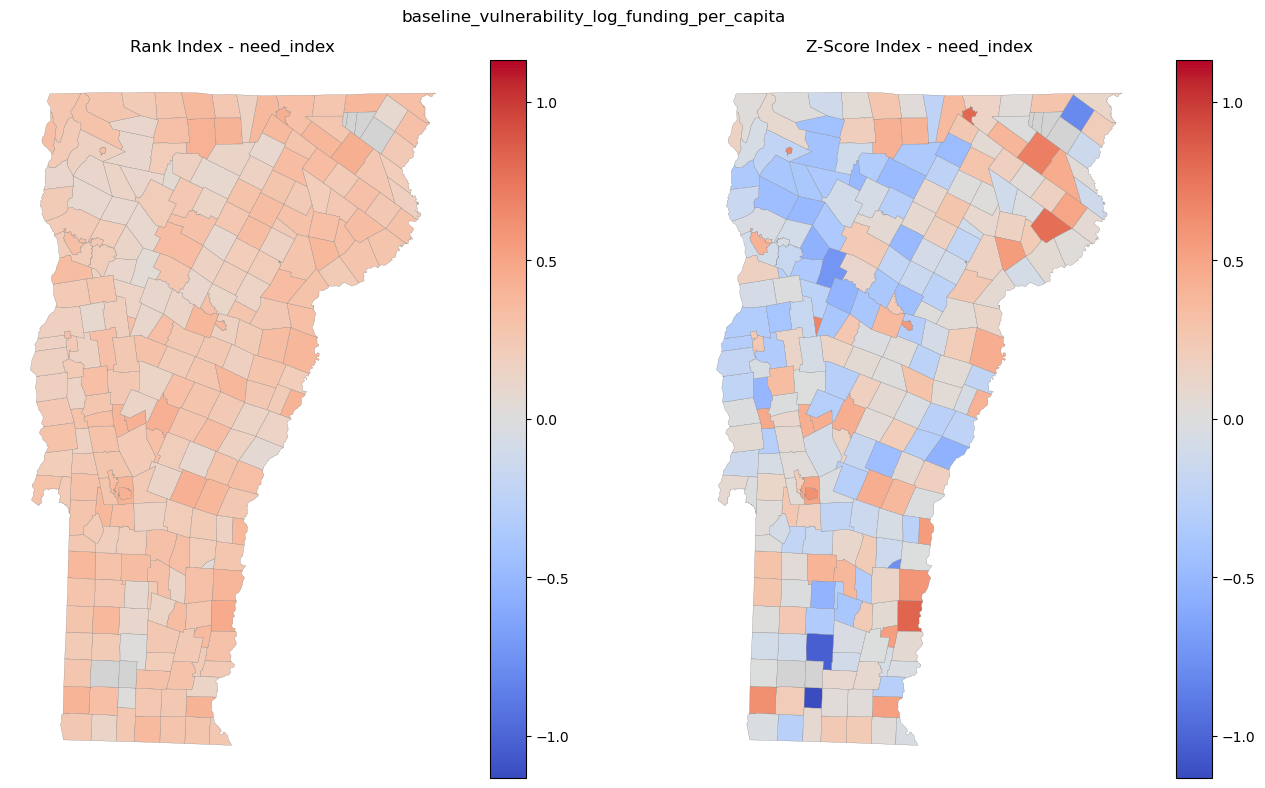


=== core_model_log_funding_per_capita ===

Index Spearman correlation (z vs rank): 0.959


{'highest_need':            town_name  need_index
 174     Rutland city    0.910000
 175     Rutland town    0.869333
 12        Barre city    0.844000
 161     Proctor town    0.844000
 213   Vergennes city    0.832000
 16   Bennington town    0.825333
 54     Coventry town    0.823333
 37   Burlington city    0.810667
 250    Winooski city    0.803333
 254   Woodstock town    0.801333,
 'lowest_need':            town_name  need_index
 9     Baltimore town    0.035333
 201    Stratton town    0.052333
 6       Averill town    0.113667
 85   Grand Isle town    0.119333
 66       Elmore town    0.123333
 153        Peru town    0.134667
 193  St. George town    0.157333
 65         Eden town    0.164000
 74      Fayston town    0.167333
 195    Stamford town    0.180000}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
82,5000929125,Granby town,0.205948,0.384667,175.0,74.0,101.0
34,5000710300,Buels gore,-0.025761,0.326667,142.0,44.0,98.0
5,5002501900,Athens town,0.206839,0.476667,176.0,124.0,52.0
181,5001164600,Sheldon town,0.580072,0.586667,220.0,169.0,51.0
80,5000128600,Goshen town,-0.004818,0.439333,147.0,98.0,49.0
168,5002360625,Roxbury town,-0.309833,0.298000,81.0,33.0,48.0
74,5000925975,Ferdinand town,0.446201,0.578667,207.0,162.5,44.5
233,5002782000,Weston town,0.244328,0.542000,182.0,143.0,39.0
170,5000361000,Rupert town,0.126805,0.507333,168.0,131.0,37.0
70,5001124925,Fairfax town,0.508370,0.611333,214.0,178.0,36.0


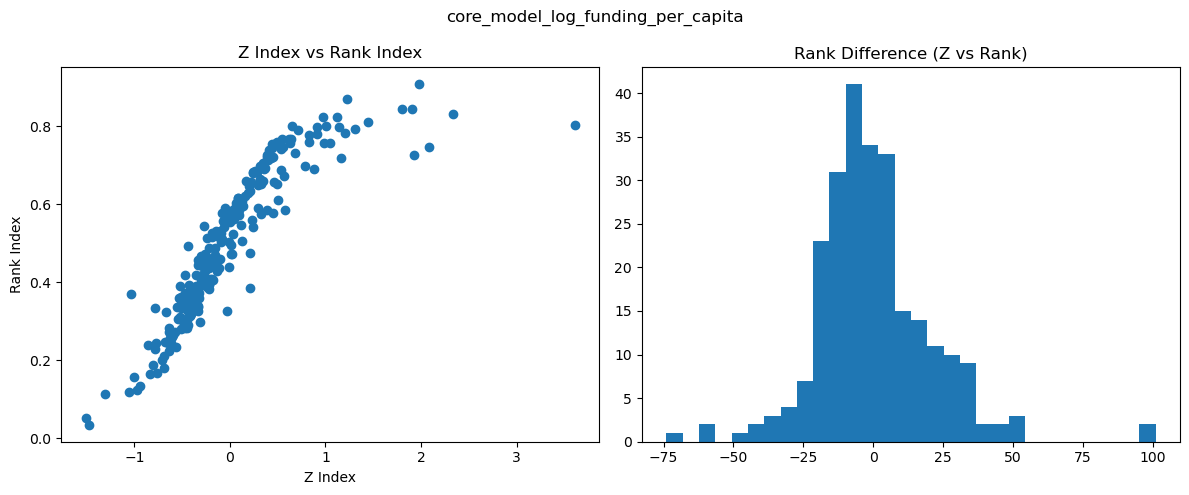

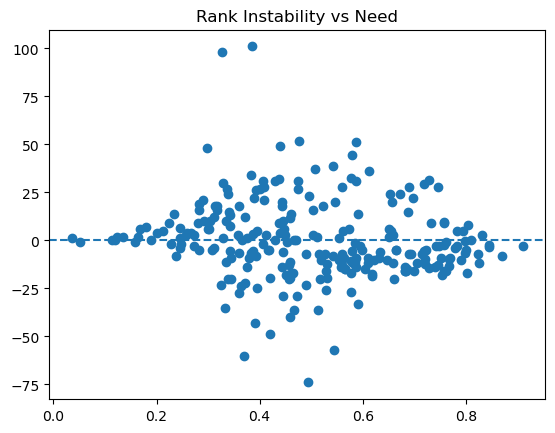

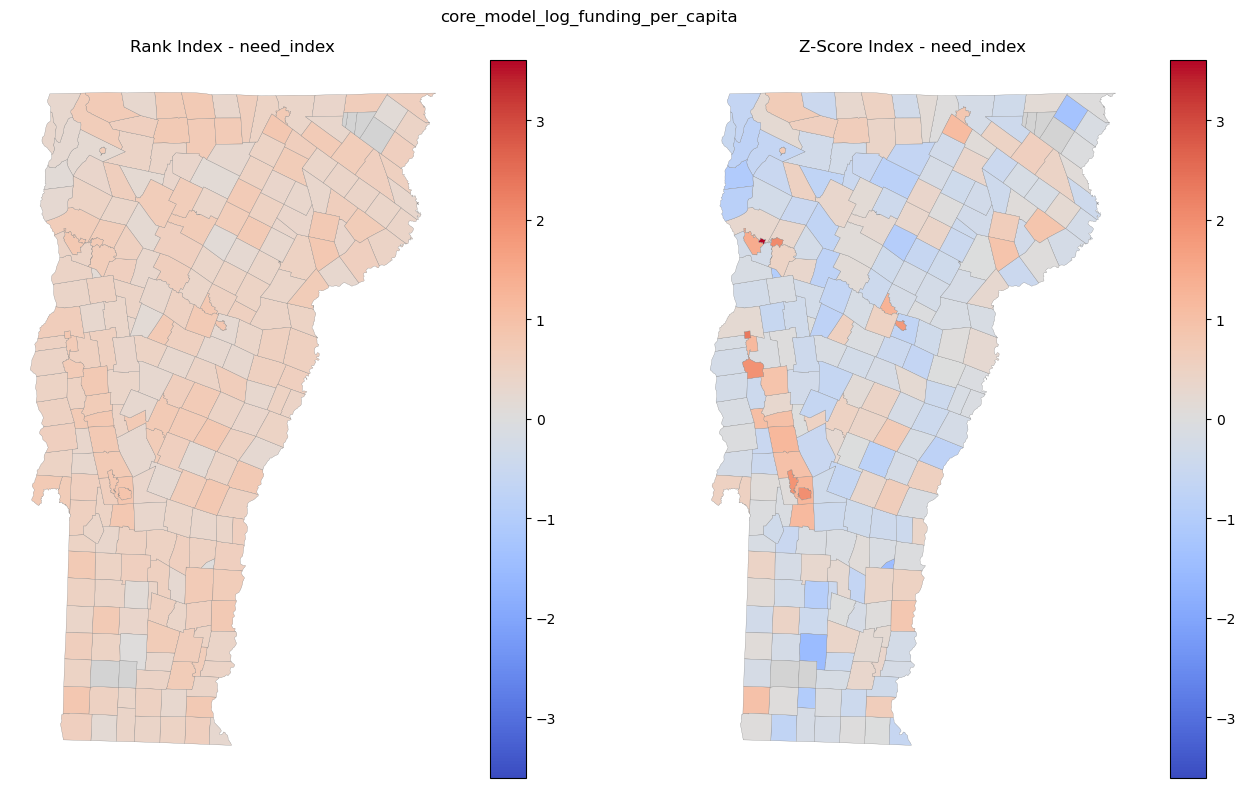


=== expanded_model_log_funding_per_capita ===

Index Spearman correlation (z vs rank): 0.969


{'highest_need':            town_name  need_index
 174     Rutland city      0.8644
 213   Vergennes city      0.8312
 54     Coventry town      0.8280
 12        Barre city      0.8112
 49    Clarendon town      0.8104
 242     Whiting town      0.8068
 16   Bennington town      0.8044
 175     Rutland town      0.7988
 67    Enosburgh town      0.7980
 172    Royalton town      0.7968,
 'lowest_need':            town_name  need_index
 6       Averill town      0.0812
 66       Elmore town      0.1228
 201    Stratton town      0.1410
 195    Stamford town      0.1556
 9     Baltimore town      0.1576
 144  North Hero town      0.1900
 74      Fayston town      0.1936
 153        Peru town      0.1952
 85   Grand Isle town      0.2032
 35        Buels gore      0.2034}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
82,5000929125,Granby town,-0.041709,0.3776,146.0,71.0,75.0
5,5002501900,Athens town,0.271238,0.5140,189.0,133.5,55.5
62,5000921250,East Haven town,-0.102949,0.3918,133.0,78.0,55.0
74,5000925975,Ferdinand town,0.463442,0.5738,206.0,157.0,49.0
193,5000170075,Starksboro town,-0.043257,0.4348,145.0,99.0,46.0
70,5001124925,Fairfax town,0.548153,0.6216,215.0,175.0,40.0
242,5002784925,Windsor town,0.298459,0.5492,190.0,150.0,40.0
179,5000564075,Sheffield town,-0.178138,0.3800,111.0,72.0,39.0
181,5001164600,Sheldon town,0.874427,0.6688,232.0,198.0,34.0
28,5000908725,Brighton town,0.546836,0.6408,214.0,182.0,32.0


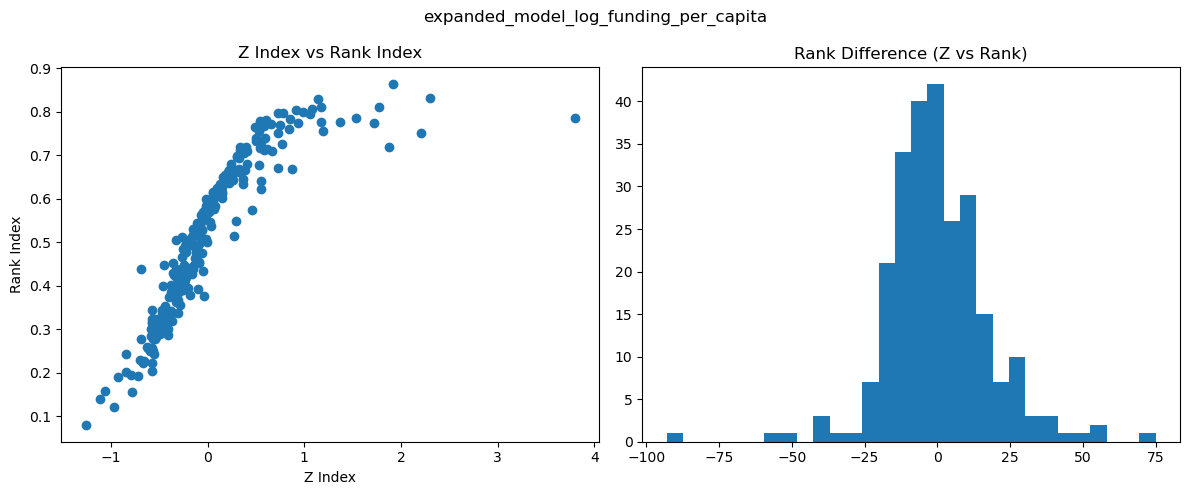

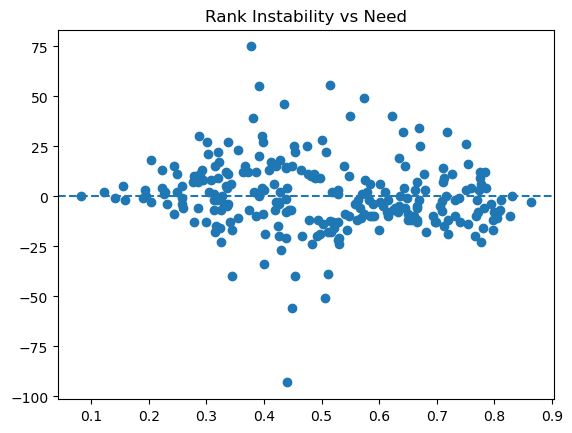

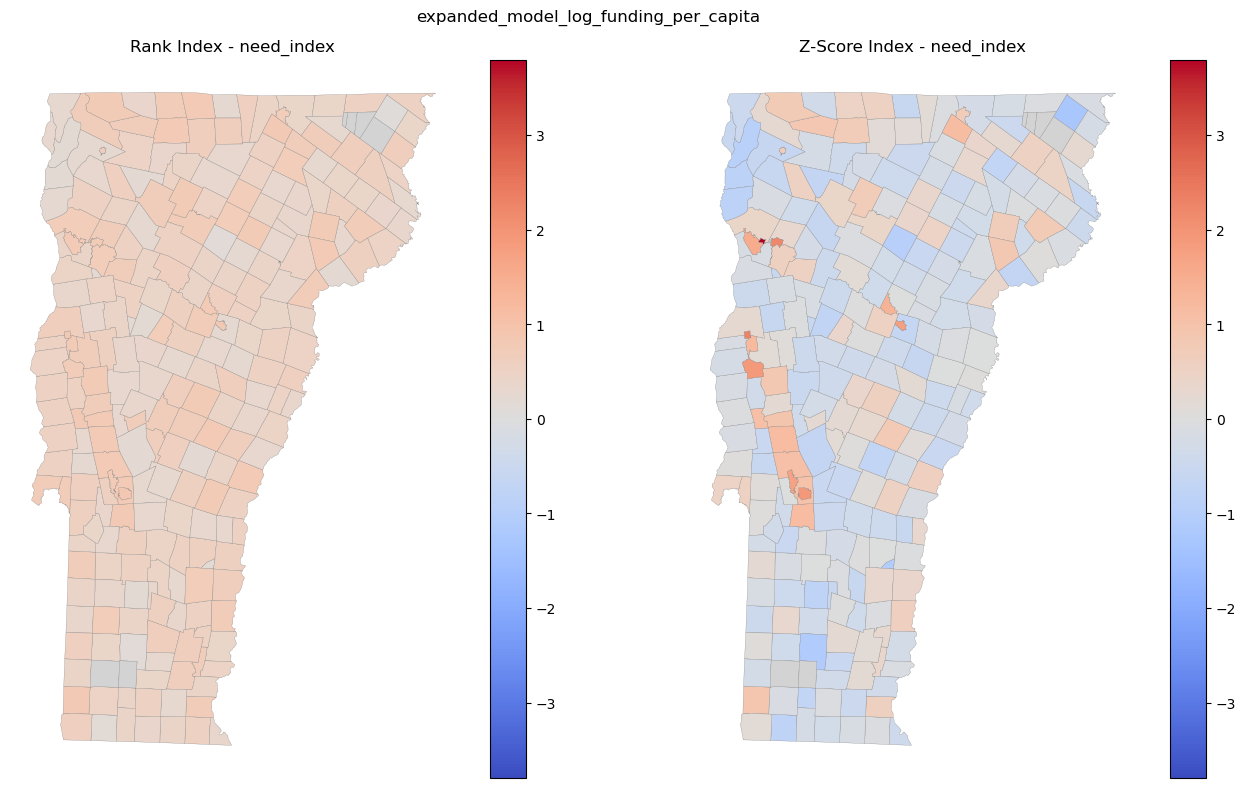


=== nfhl_model_log_funding_per_capita ===

Index Spearman correlation (z vs rank): 0.910


{'highest_need':            town_name  need_index
 243  Whitingham town       0.878
 174     Rutland city       0.870
 232  West Haven town       0.866
 170  Rockingham town       0.851
 161     Proctor town       0.840
 175     Rutland town       0.840
 230       Wells town       0.830
 25      Brandon town       0.827
 155   Pittsford town       0.818
 169   Rochester town       0.815,
 'lowest_need':            town_name  need_index
 9     Baltimore town      0.1210
 66       Elmore town      0.1410
 150      Panton town      0.1520
 15    Belvidere town      0.1620
 184     Sheldon town      0.1630
 228  Waterville town      0.1640
 72    Fairfield town      0.1650
 103    Irasburg town      0.1660
 65         Eden town      0.1820
 6       Averill town      0.2085}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
34,5000710300,Buels gore,0.421613,0.3435,197.0,48.0,149.0
82,5000929125,Granby town,0.686274,0.4530,224.0,110.5,113.5
216,5000176075,Waltham town,0.243299,0.4020,179.0,81.0,98.0
74,5000925975,Ferdinand town,0.620013,0.4740,217.0,122.0,95.0
33,5000910075,Brunswick town,0.000287,0.3870,146.0,73.5,72.5
212,5000975175,Victory town,1.114189,0.5880,238.0,168.0,70.0
164,5000759275,Richmond town,0.630276,0.5760,221.0,162.0,59.0
49,5000714875,Colchester town,1.541525,0.6410,243.0,186.0,57.0
68,5000724175,Essex town,0.929531,0.6050,232.0,178.0,54.0
126,5000745250,Milton town,0.439155,0.5310,198.0,144.0,54.0


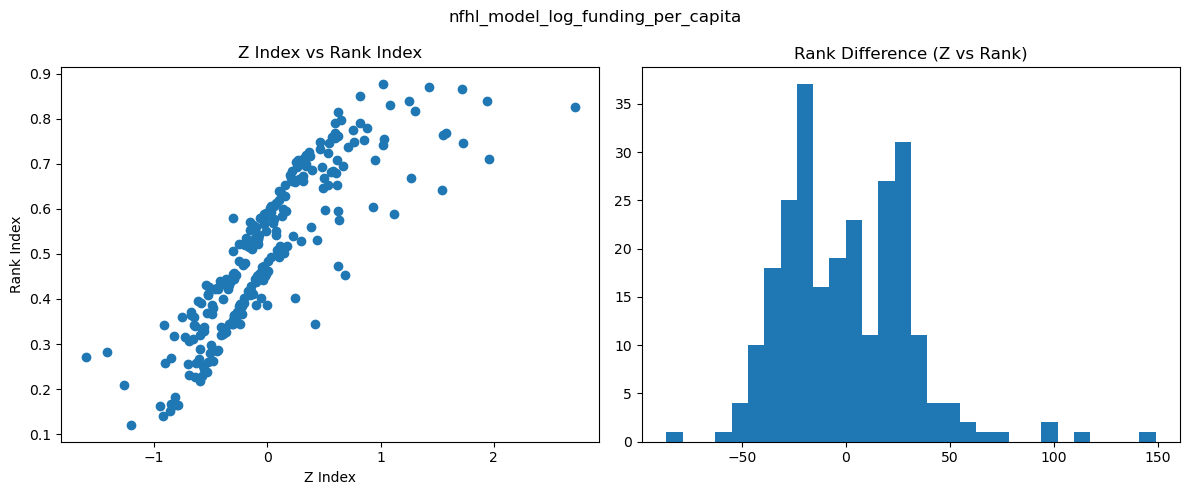

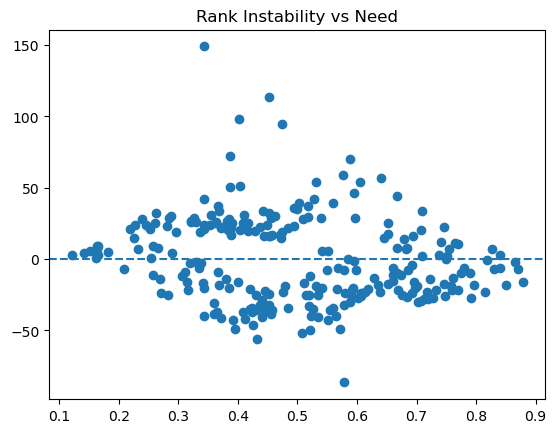

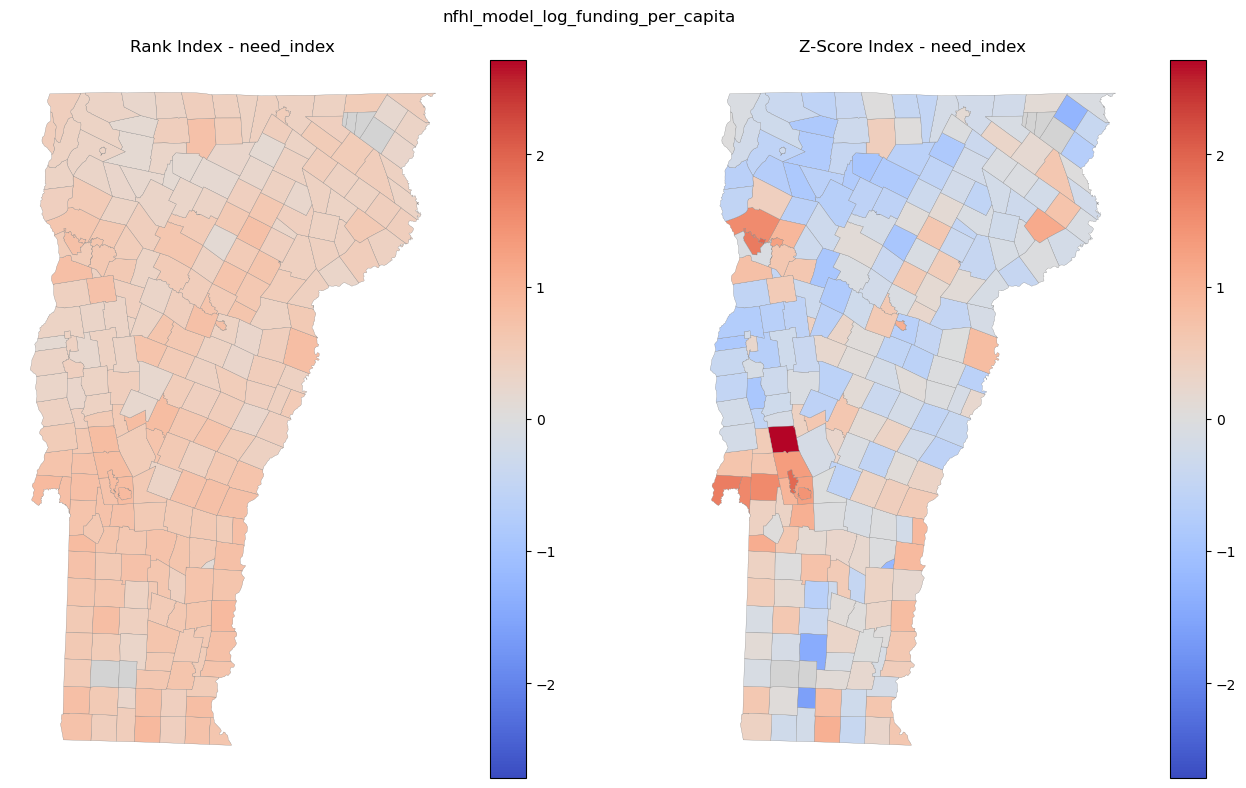


=== claims_only_log_funding_per_capita ===

Index Spearman correlation (z vs rank): 1.000


{'highest_need':             town_name  need_index
 118       Ludlow town       0.500
 19        Berlin town       0.498
 133     Moretown town       0.496
 254    Woodstock town       0.494
 43     Cavendish town       0.492
 239       Weston town       0.490
 132   Montpelier city       0.488
 32     Brookline town       0.486
 246   Wilmington town       0.484
 27   Bridgewater town       0.482,
 'lowest_need':            town_name  need_index
 0       Addison town       0.106
 1        Albany town       0.106
 2       Alburgh town       0.106
 5        Athens town       0.106
 6       Averill town       0.106
 8   Bakersfield town       0.106
 9     Baltimore town       0.106
 10      Barnard town       0.106
 15    Belvidere town       0.106
 17       Benson town       0.106}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
0,5000100325,Addison town,-0.196297,0.106,53.0,53.0,0.0
1,5001900475,Albany town,-0.196297,0.106,53.0,53.0,0.0
2,5001300860,Alburgh town,-0.196297,0.106,53.0,53.0,0.0
3,5002701300,Andover town,-0.085151,0.372,186.0,186.0,0.0
4,5000301450,Arlington town,-0.164953,0.318,159.0,159.0,0.0
5,5002501900,Athens town,-0.196297,0.106,53.0,53.0,0.0
6,5000902125,Averill town,-0.196297,0.106,53.0,53.0,0.0
7,5001102500,Bakersfield town,-0.196297,0.106,53.0,53.0,0.0
8,5002702575,Baltimore town,-0.196297,0.106,53.0,53.0,0.0
9,5002702725,Barnard town,-0.196297,0.106,53.0,53.0,0.0


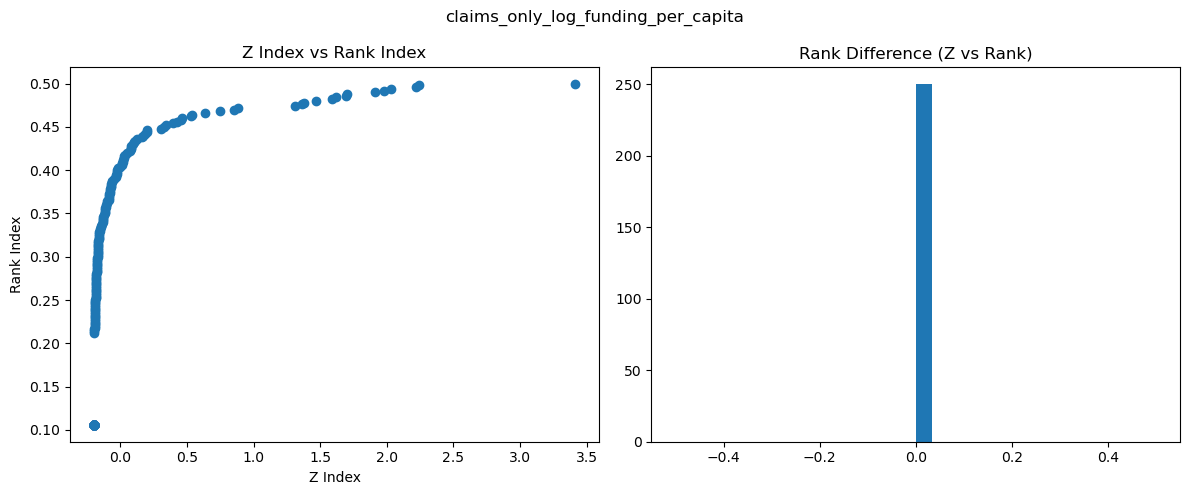

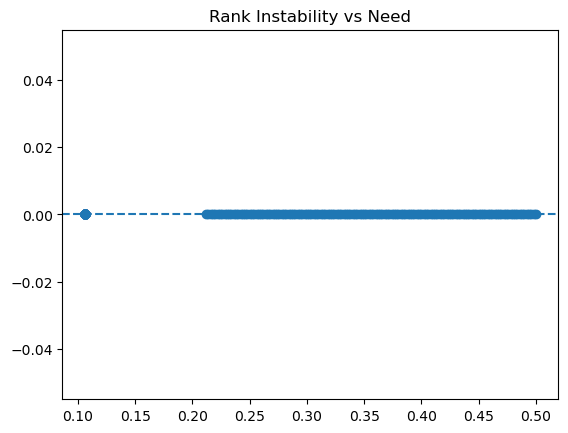

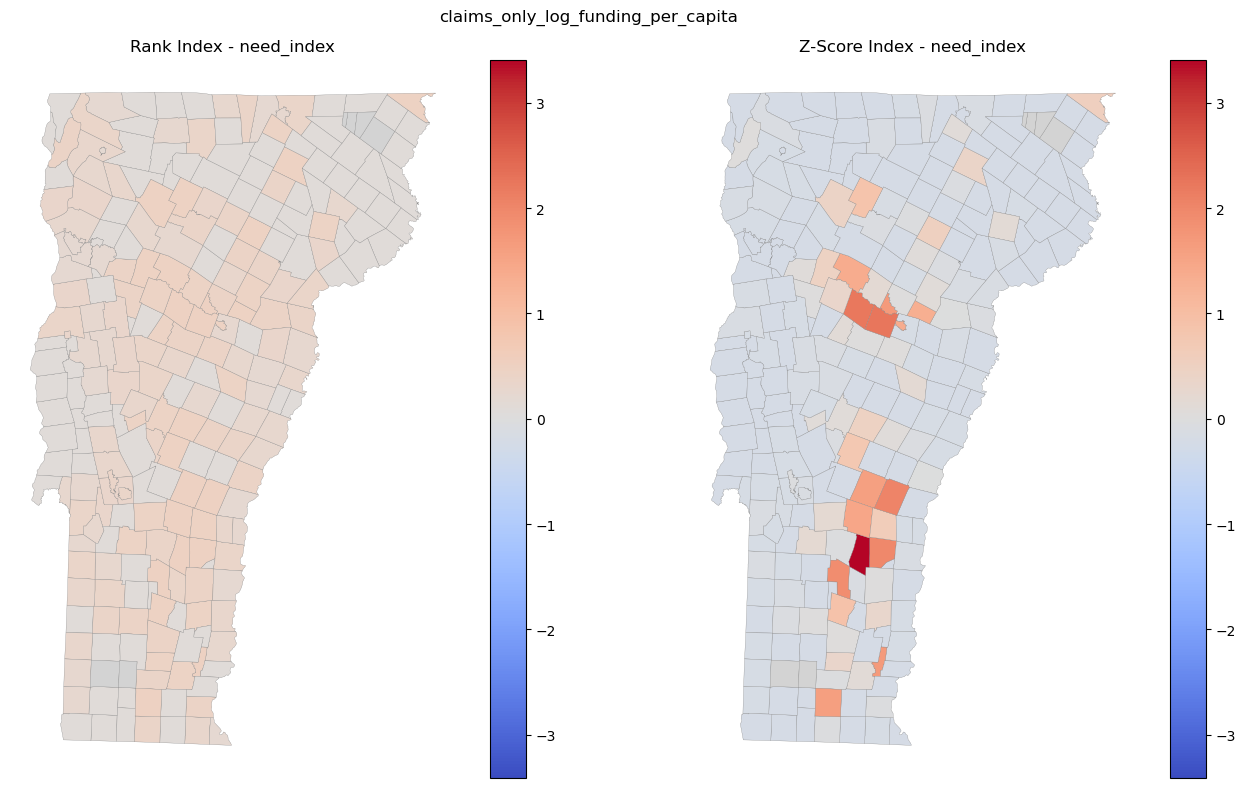


=== combined_log_funding_per_capita ===

Index Spearman correlation (z vs rank): 0.951


{'highest_need':            town_name  need_index
 174     Rutland city       0.882
 216     Victory town       0.847
 161     Proctor town       0.840
 175     Rutland town       0.836
 240   Weybridge town       0.831
 54     Coventry town       0.829
 232  West Haven town       0.828
 155   Pittsford town       0.814
 25      Brandon town       0.813
 112   Leicester town       0.809,
 'lowest_need':            town_name  need_index
 9     Baltimore town      0.0360
 201    Stratton town      0.0465
 66       Elmore town      0.0840
 193  St. George town      0.1040
 85   Grand Isle town      0.1310
 6       Averill town      0.1435
 153        Peru town      0.1590
 74      Fayston town      0.1730
 65         Eden town      0.1750
 13        Barre town      0.1890}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
34,5000710300,Buels gore,0.047183,0.2645,149.0,31.0,118.0
82,5000929125,Granby town,0.724236,0.4960,231.0,121.0,110.0
181,5001164600,Sheldon town,0.502935,0.5520,215.0,148.0,67.0
168,5002360625,Roxbury town,-0.053962,0.3750,130.0,64.0,66.0
233,5002782000,Weston town,0.329439,0.5160,189.0,133.0,56.0
170,5000361000,Rupert town,0.364435,0.5420,199.0,144.5,54.5
70,5001124925,Fairfax town,0.356313,0.5400,197.0,143.0,54.0
80,5000128600,Goshen town,0.281538,0.5140,183.0,130.0,53.0
67,5000724400,Essex Junction city,1.909337,0.6760,246.0,198.0,48.0
85,5001930175,Greensboro town,0.200844,0.5290,177.0,138.0,39.0


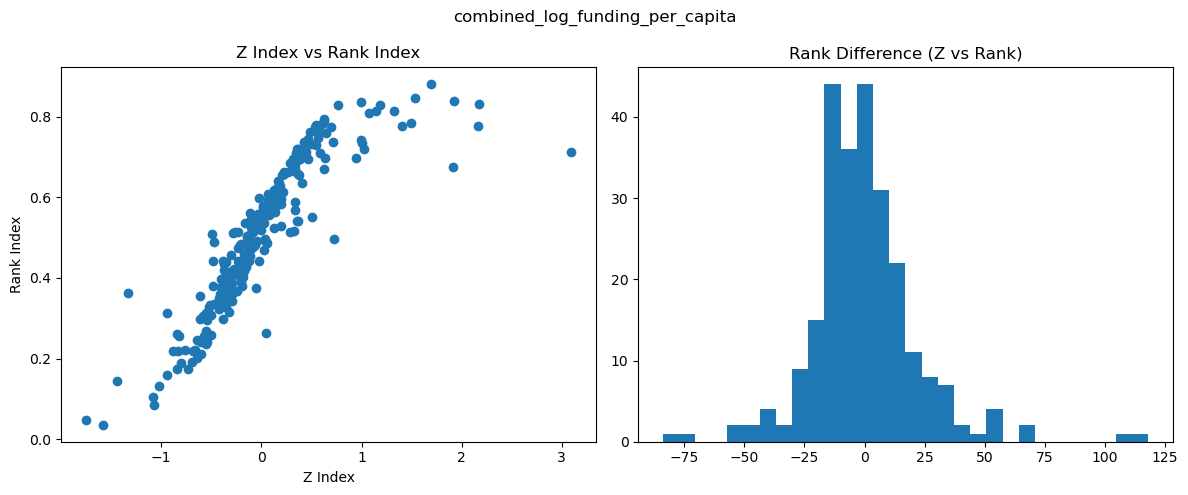

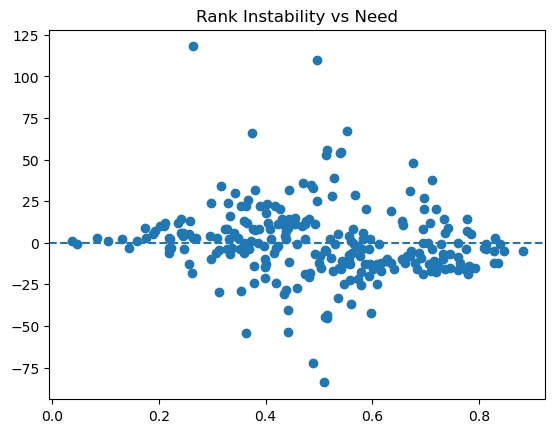

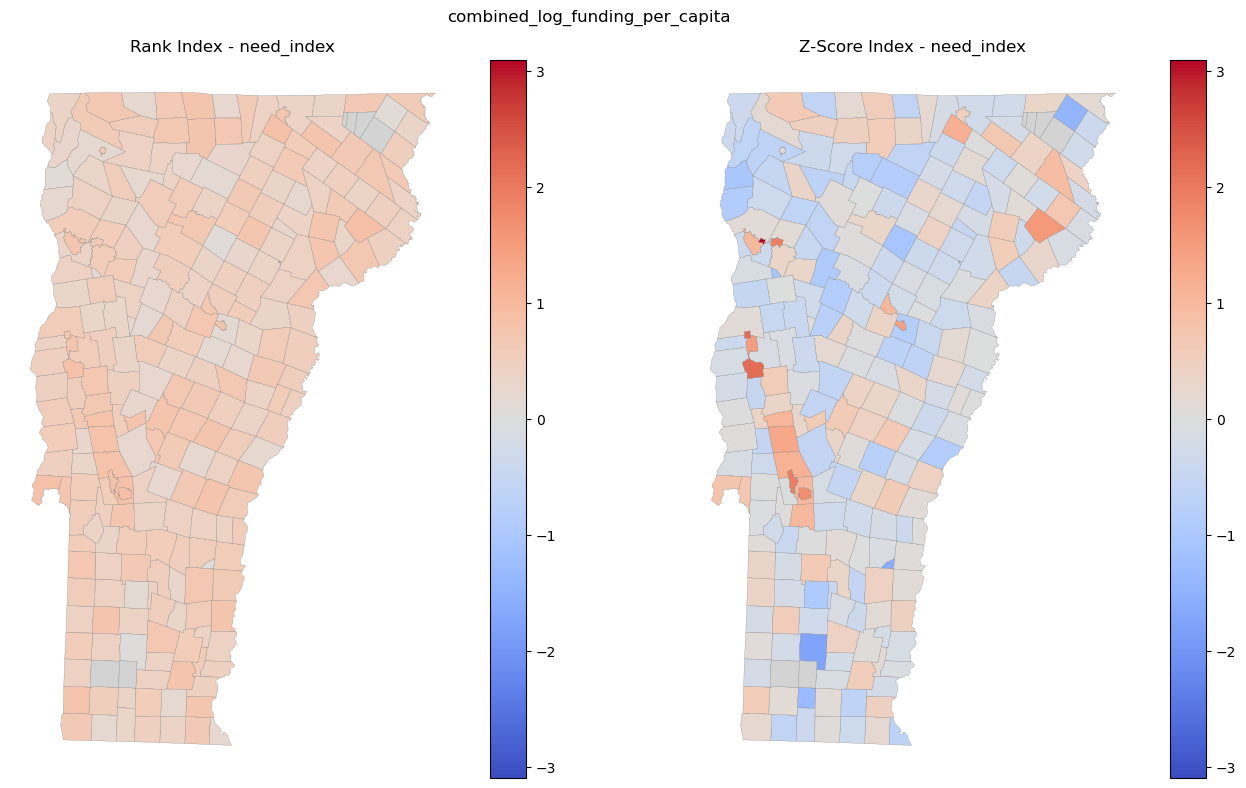


=== baseline_exposure_log_funding_per_occupied_unit ===

Index Spearman correlation (z vs rank): 1.000


{'highest_need':                town_name  need_index
 250        Winooski city       0.500
 68   Essex Junction city       0.498
 213       Vergennes city       0.496
 240       Weybridge town       0.494
 161         Proctor town       0.492
 174         Rutland city       0.490
 12            Barre city       0.488
 25          Brandon town       0.486
 132      Montpelier city       0.484
 37       Burlington city       0.482,
 'lowest_need':               town_name  need_index
 9        Baltimore town       0.006
 85      Grand Isle town       0.006
 104  Isle La Motte town       0.006
 144     North Hero town       0.006
 193     St. George town       0.006
 35           Buels gore       0.012
 189     South Hero town       0.014
 2          Alburgh town       0.016
 238       Westmore town       0.018
 110          Kirby town       0.020}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
0,5000100325,Addison town,-0.069905,0.274,137.0,137.0,0.0
1,5001900475,Albany town,0.026352,0.330,165.0,165.0,0.0
2,5001300860,Alburgh town,-0.654530,0.016,8.0,8.0,0.0
3,5002701300,Andover town,-0.325323,0.120,60.0,60.0,0.0
4,5000301450,Arlington town,0.192681,0.386,193.0,193.0,0.0
5,5002501900,Athens town,-0.325029,0.122,61.0,61.0,0.0
6,5000902125,Averill town,-0.504720,0.026,13.0,13.0,0.0
7,5001102500,Bakersfield town,-0.190319,0.192,96.0,96.0,0.0
8,5002702575,Baltimore town,-0.707679,0.006,3.0,3.0,0.0
9,5002702725,Barnard town,-0.347259,0.096,48.0,48.0,0.0


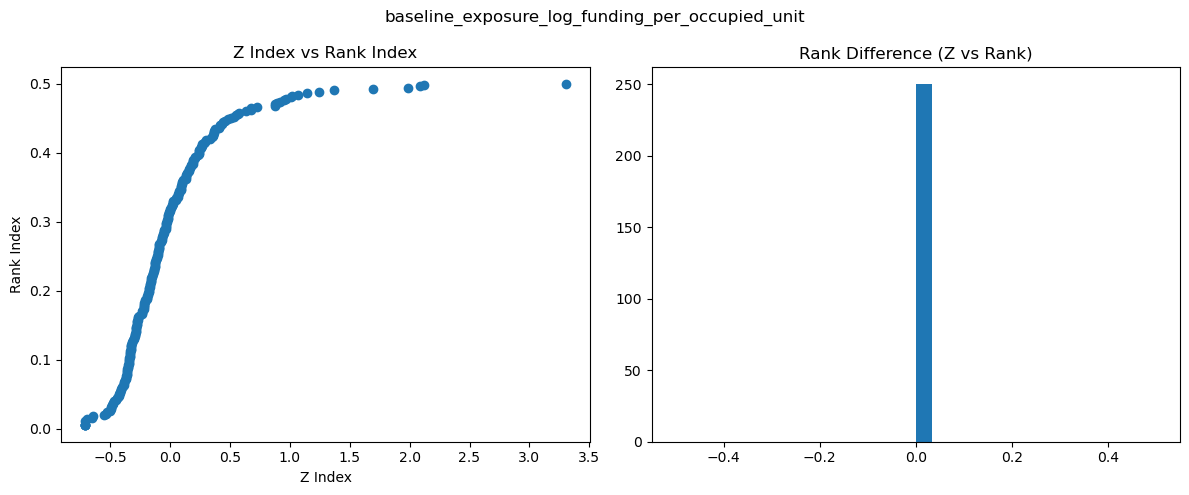

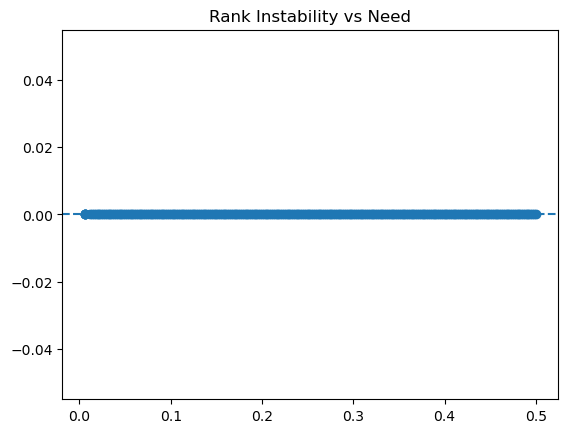

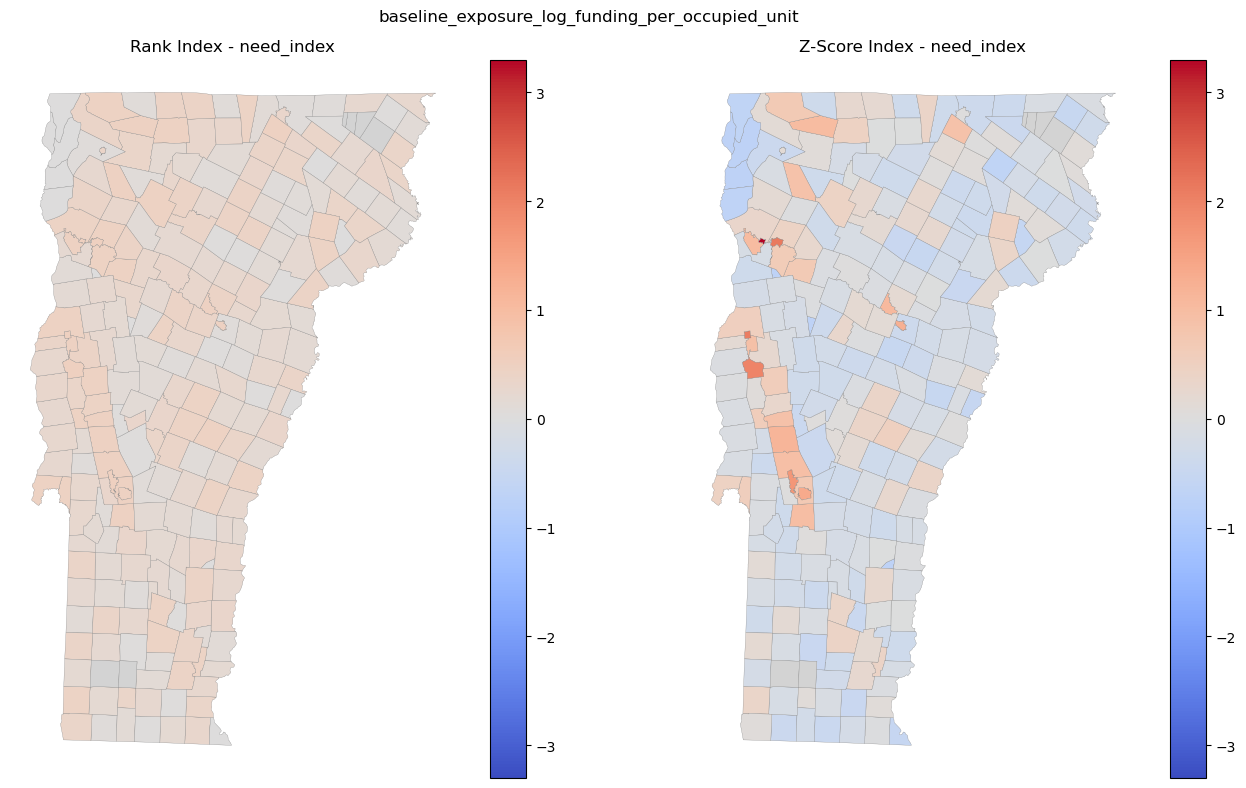


=== baseline_vulnerability_log_funding_per_occupied_unit ===

Index Spearman correlation (z vs rank): 0.958


{'highest_need':             town_name  need_index
 170   Rockingham town    0.460667
 29      Brighton town    0.442000
 142      Newport city    0.438667
 27   Bridgewater town    0.430667
 169    Rochester town    0.426667
 174      Rutland city    0.420000
 131   Montgomery town    0.417333
 26   Brattleboro town    0.416000
 73       Fairlee town    0.416000
 235    Westfield town    0.413333,
 'lowest_need':            town_name  need_index
 179   Searsburg town    0.012333
 201    Stratton town    0.016333
 9     Baltimore town    0.029333
 22       Bolton town    0.045333
 228  Waterville town    0.058000
 147     Norwich town    0.062667
 153        Peru town    0.076667
 65         Eden town    0.080000
 130     Monkton town    0.085333
 6       Averill town    0.087667}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
82,5000929125,Granby town,0.500635,0.250667,235.0,117.0,118.0
74,5000925975,Ferdinand town,0.456461,0.264667,233.0,131.0,102.0
216,5000176075,Waltham town,0.250834,0.244667,206.0,109.0,97.0
33,5000910075,Brunswick town,0.043310,0.206667,143.0,72.0,71.0
168,5002360625,Roxbury town,0.055390,0.222000,150.0,86.0,64.0
236,5000183800,Whiting town,0.474187,0.299333,234.0,170.5,63.5
34,5000710300,Buels gore,0.681316,0.314667,246.0,183.0,63.0
170,5000361000,Rupert town,0.279022,0.287333,212.0,156.0,56.0
244,5000785150,Winooski city,0.307388,0.303333,217.0,174.0,43.0
136,5000547725,Newark town,0.038037,0.234667,141.0,99.0,42.0


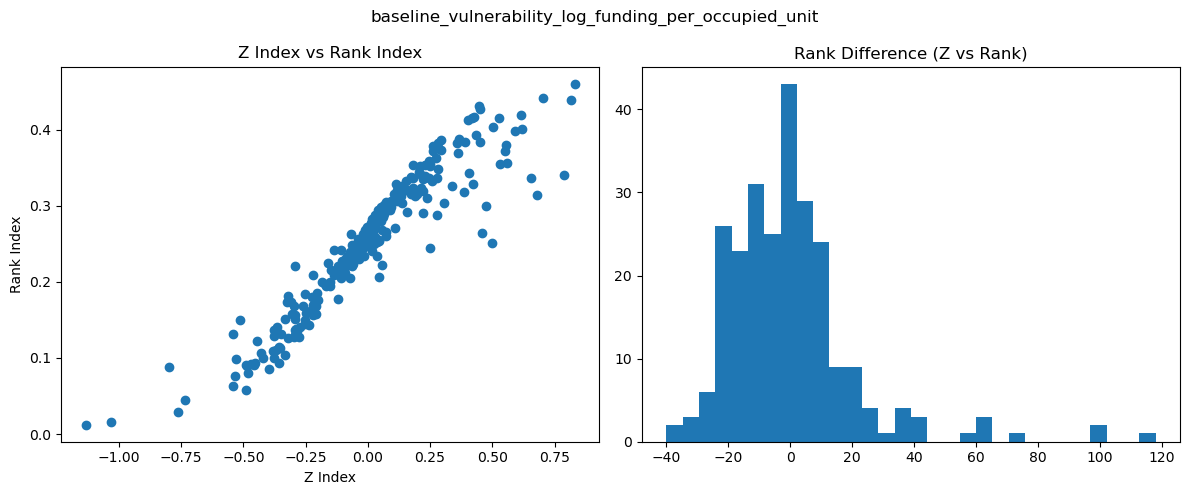

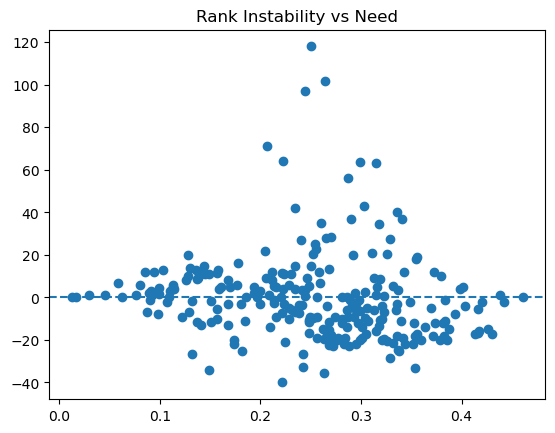

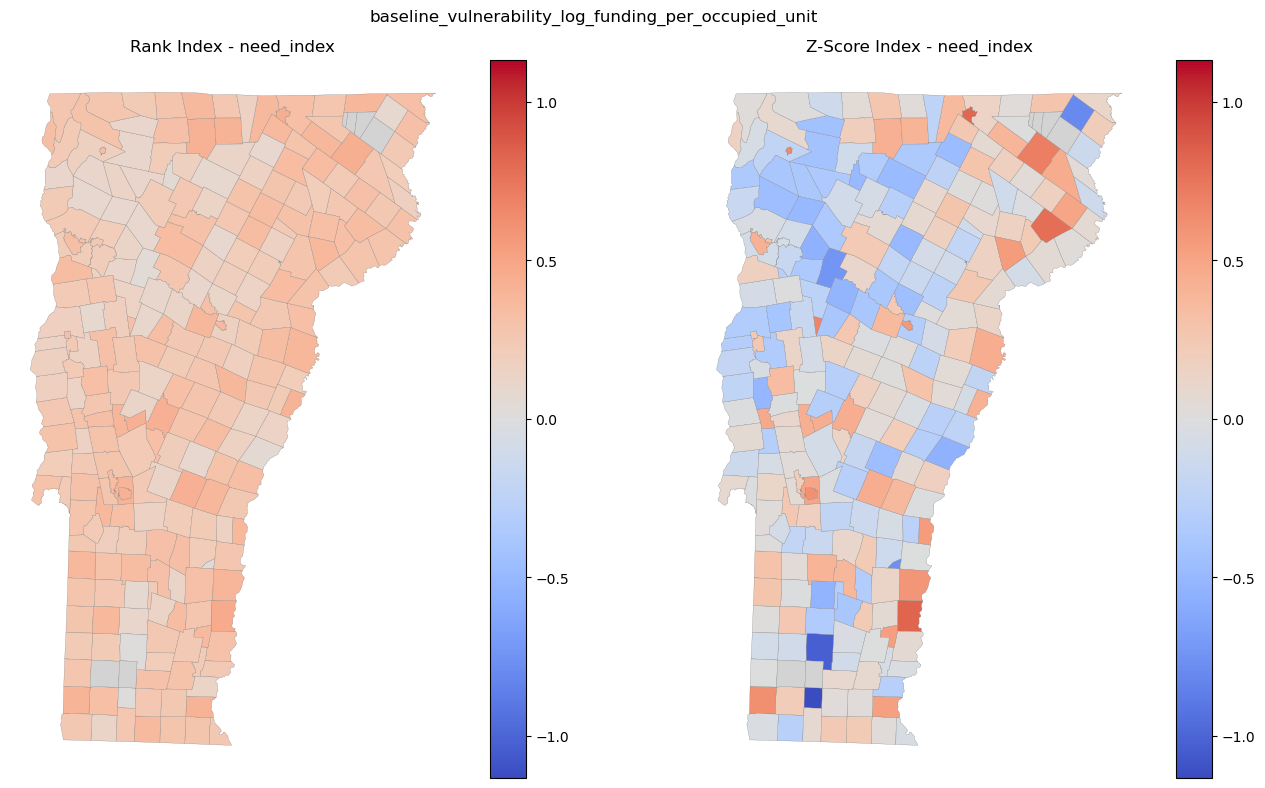


=== core_model_log_funding_per_occupied_unit ===

Index Spearman correlation (z vs rank): 0.959


{'highest_need':            town_name  need_index
 174     Rutland city    0.910000
 175     Rutland town    0.869333
 12        Barre city    0.844000
 161     Proctor town    0.844000
 213   Vergennes city    0.832000
 16   Bennington town    0.825333
 54     Coventry town    0.823333
 37   Burlington city    0.810667
 250    Winooski city    0.803333
 254   Woodstock town    0.801333,
 'lowest_need':            town_name  need_index
 9     Baltimore town    0.035333
 201    Stratton town    0.052333
 6       Averill town    0.113667
 85   Grand Isle town    0.119333
 66       Elmore town    0.123333
 153        Peru town    0.134667
 193  St. George town    0.157333
 65         Eden town    0.164000
 74      Fayston town    0.167333
 195    Stamford town    0.180000}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
82,5000929125,Granby town,0.205948,0.384667,175.0,74.0,101.0
34,5000710300,Buels gore,-0.025761,0.326667,142.0,44.0,98.0
5,5002501900,Athens town,0.206839,0.476667,176.0,124.0,52.0
181,5001164600,Sheldon town,0.580072,0.586667,220.0,169.0,51.0
80,5000128600,Goshen town,-0.004818,0.439333,147.0,98.0,49.0
168,5002360625,Roxbury town,-0.309833,0.298000,81.0,33.0,48.0
74,5000925975,Ferdinand town,0.446201,0.578667,207.0,162.5,44.5
233,5002782000,Weston town,0.244328,0.542000,182.0,143.0,39.0
170,5000361000,Rupert town,0.126805,0.507333,168.0,131.0,37.0
70,5001124925,Fairfax town,0.508370,0.611333,214.0,178.0,36.0


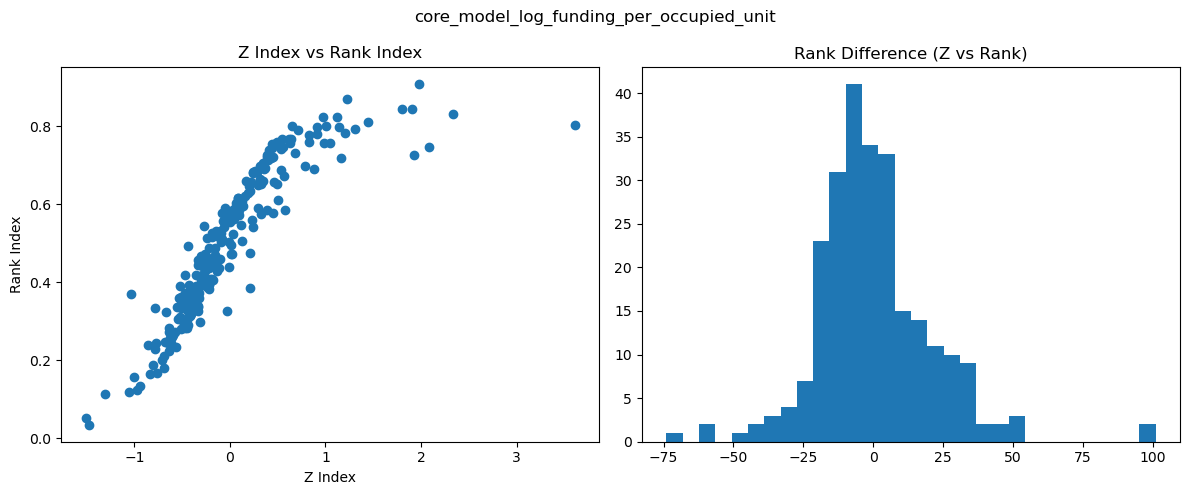

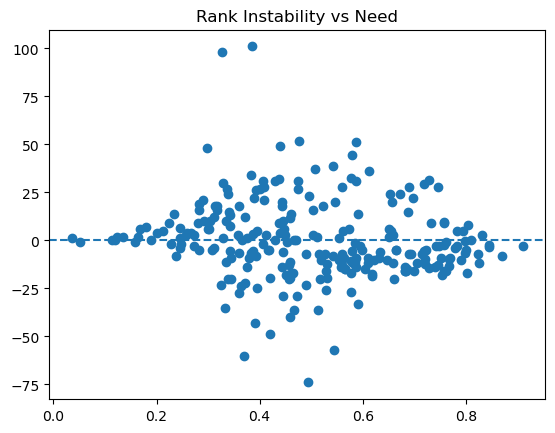

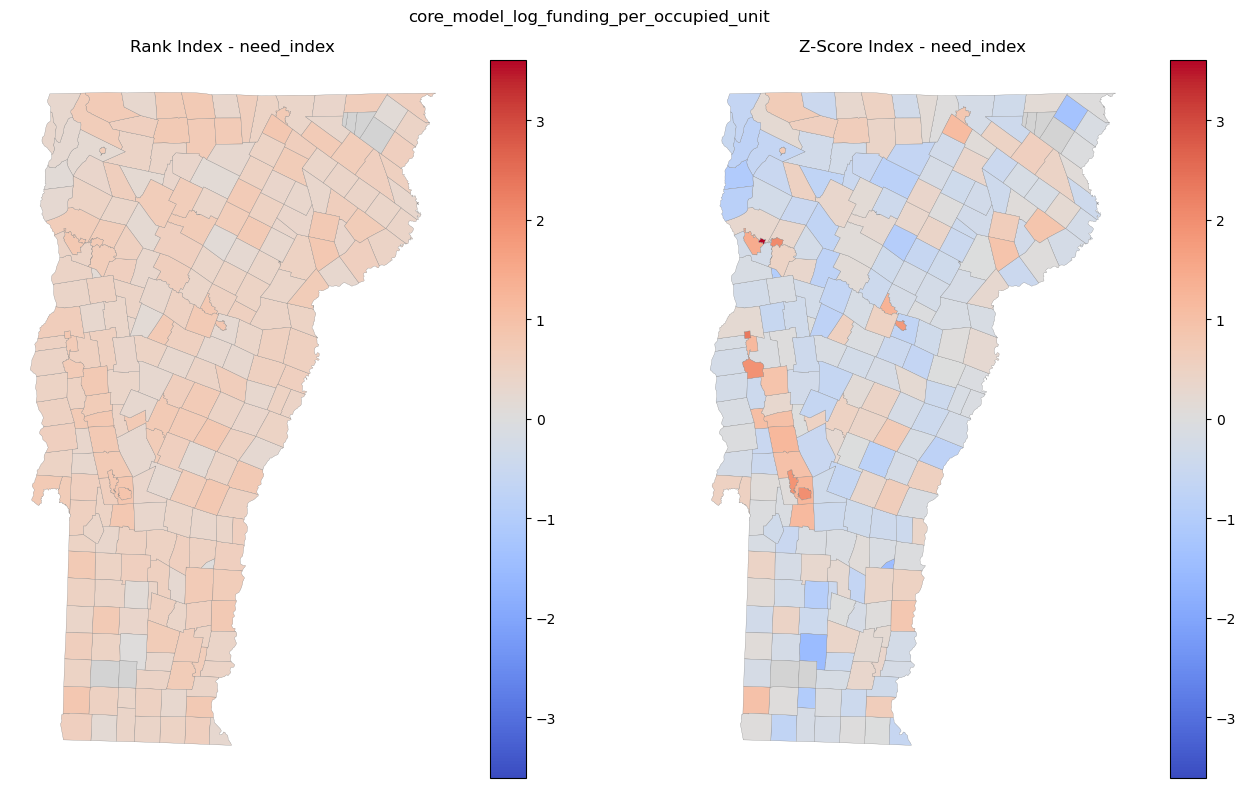


=== expanded_model_log_funding_per_occupied_unit ===

Index Spearman correlation (z vs rank): 0.969


{'highest_need':            town_name  need_index
 174     Rutland city      0.8644
 213   Vergennes city      0.8312
 54     Coventry town      0.8280
 12        Barre city      0.8112
 49    Clarendon town      0.8104
 242     Whiting town      0.8068
 16   Bennington town      0.8044
 175     Rutland town      0.7988
 67    Enosburgh town      0.7980
 172    Royalton town      0.7968,
 'lowest_need':            town_name  need_index
 6       Averill town      0.0812
 66       Elmore town      0.1228
 201    Stratton town      0.1410
 195    Stamford town      0.1556
 9     Baltimore town      0.1576
 144  North Hero town      0.1900
 74      Fayston town      0.1936
 153        Peru town      0.1952
 85   Grand Isle town      0.2032
 35        Buels gore      0.2034}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
82,5000929125,Granby town,-0.041709,0.3776,146.0,71.0,75.0
5,5002501900,Athens town,0.271238,0.5140,189.0,133.5,55.5
62,5000921250,East Haven town,-0.102949,0.3918,133.0,78.0,55.0
74,5000925975,Ferdinand town,0.463442,0.5738,206.0,157.0,49.0
193,5000170075,Starksboro town,-0.043257,0.4348,145.0,99.0,46.0
70,5001124925,Fairfax town,0.548153,0.6216,215.0,175.0,40.0
242,5002784925,Windsor town,0.298459,0.5492,190.0,150.0,40.0
179,5000564075,Sheffield town,-0.178138,0.3800,111.0,72.0,39.0
181,5001164600,Sheldon town,0.874427,0.6688,232.0,198.0,34.0
28,5000908725,Brighton town,0.546836,0.6408,214.0,182.0,32.0


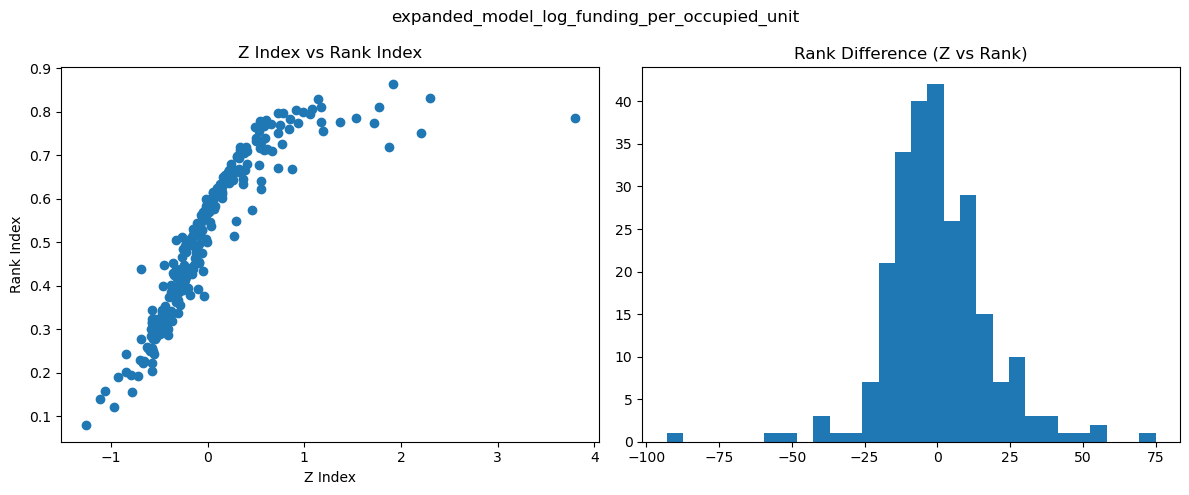

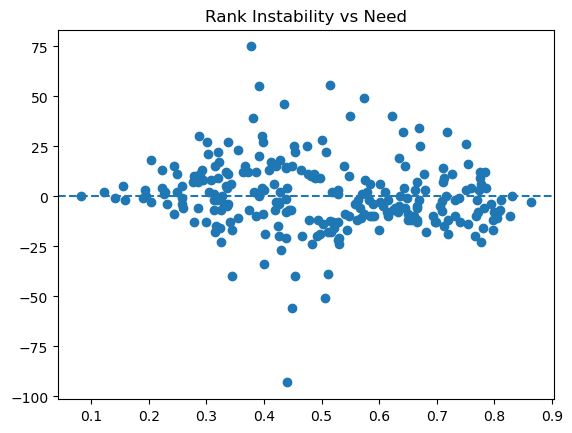

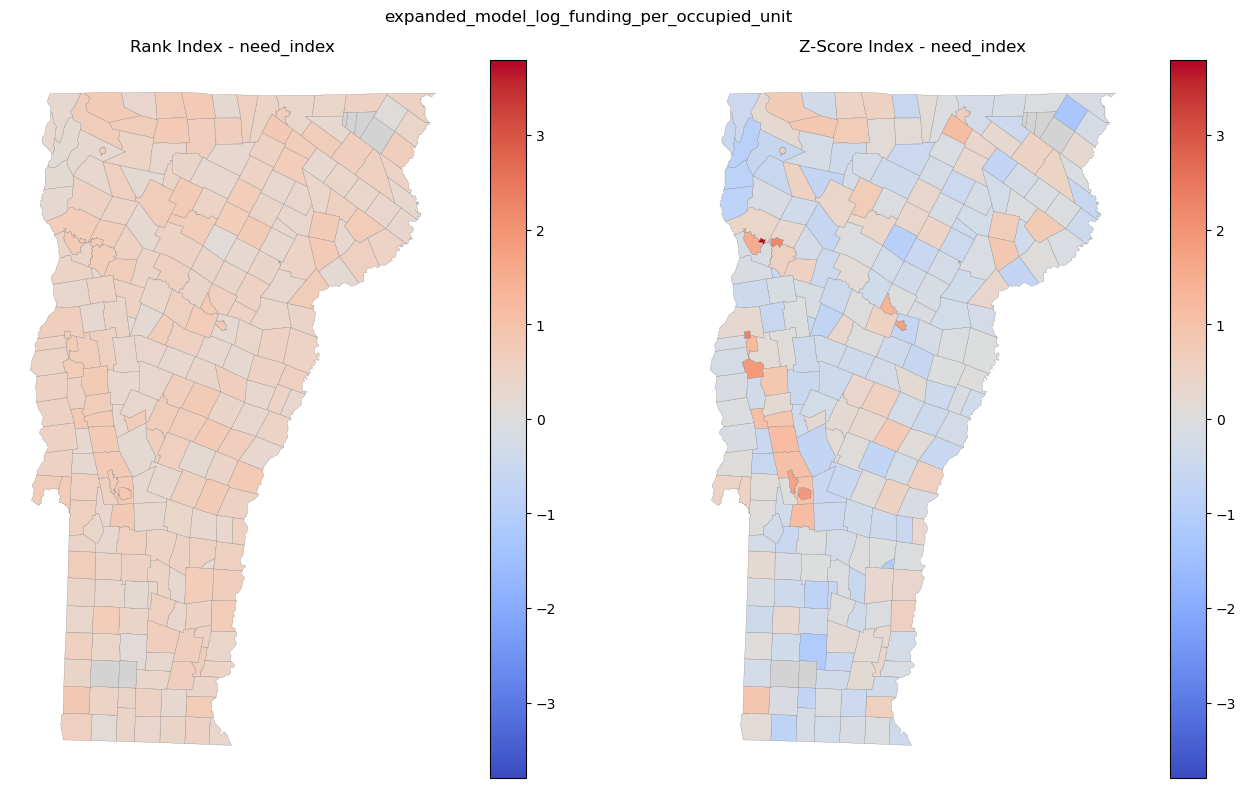


=== nfhl_model_log_funding_per_occupied_unit ===

Index Spearman correlation (z vs rank): 0.910


{'highest_need':            town_name  need_index
 243  Whitingham town       0.878
 174     Rutland city       0.870
 232  West Haven town       0.866
 170  Rockingham town       0.851
 161     Proctor town       0.840
 175     Rutland town       0.840
 230       Wells town       0.830
 25      Brandon town       0.827
 155   Pittsford town       0.818
 169   Rochester town       0.815,
 'lowest_need':            town_name  need_index
 9     Baltimore town      0.1210
 66       Elmore town      0.1410
 150      Panton town      0.1520
 15    Belvidere town      0.1620
 184     Sheldon town      0.1630
 228  Waterville town      0.1640
 72    Fairfield town      0.1650
 103    Irasburg town      0.1660
 65         Eden town      0.1820
 6       Averill town      0.2085}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
34,5000710300,Buels gore,0.421613,0.3435,197.0,48.0,149.0
82,5000929125,Granby town,0.686274,0.4530,224.0,110.5,113.5
216,5000176075,Waltham town,0.243299,0.4020,179.0,81.0,98.0
74,5000925975,Ferdinand town,0.620013,0.4740,217.0,122.0,95.0
33,5000910075,Brunswick town,0.000287,0.3870,146.0,73.5,72.5
212,5000975175,Victory town,1.114189,0.5880,238.0,168.0,70.0
164,5000759275,Richmond town,0.630276,0.5760,221.0,162.0,59.0
49,5000714875,Colchester town,1.541525,0.6410,243.0,186.0,57.0
68,5000724175,Essex town,0.929531,0.6050,232.0,178.0,54.0
126,5000745250,Milton town,0.439155,0.5310,198.0,144.0,54.0


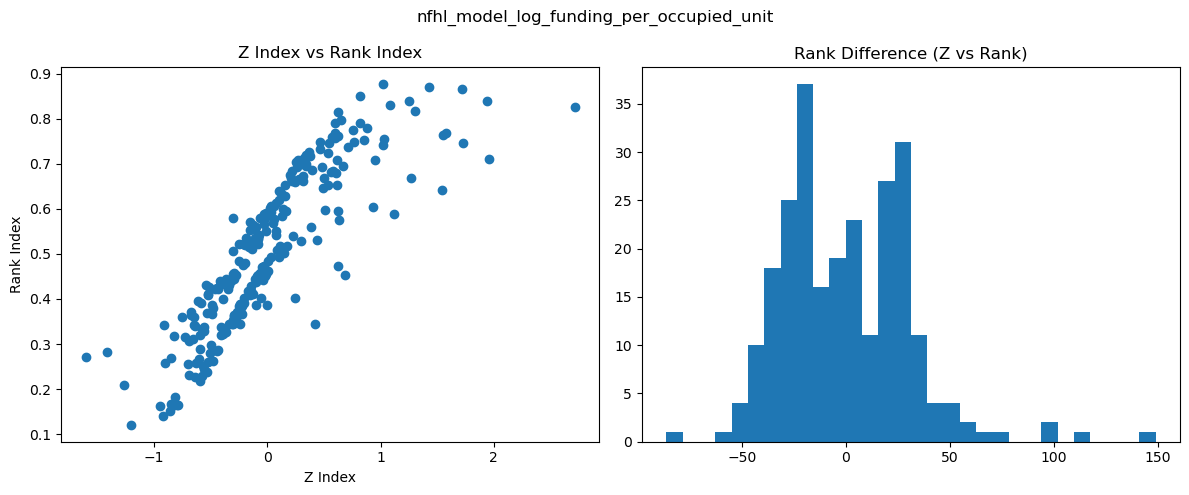

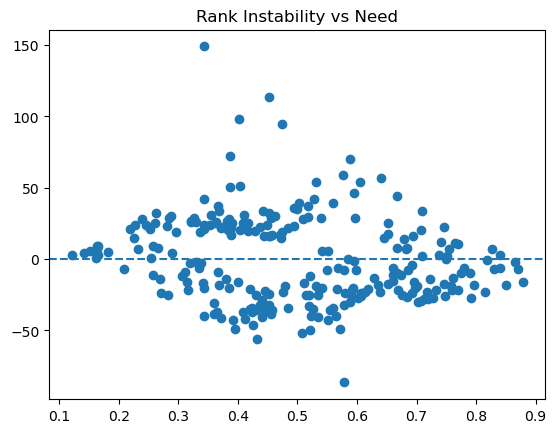

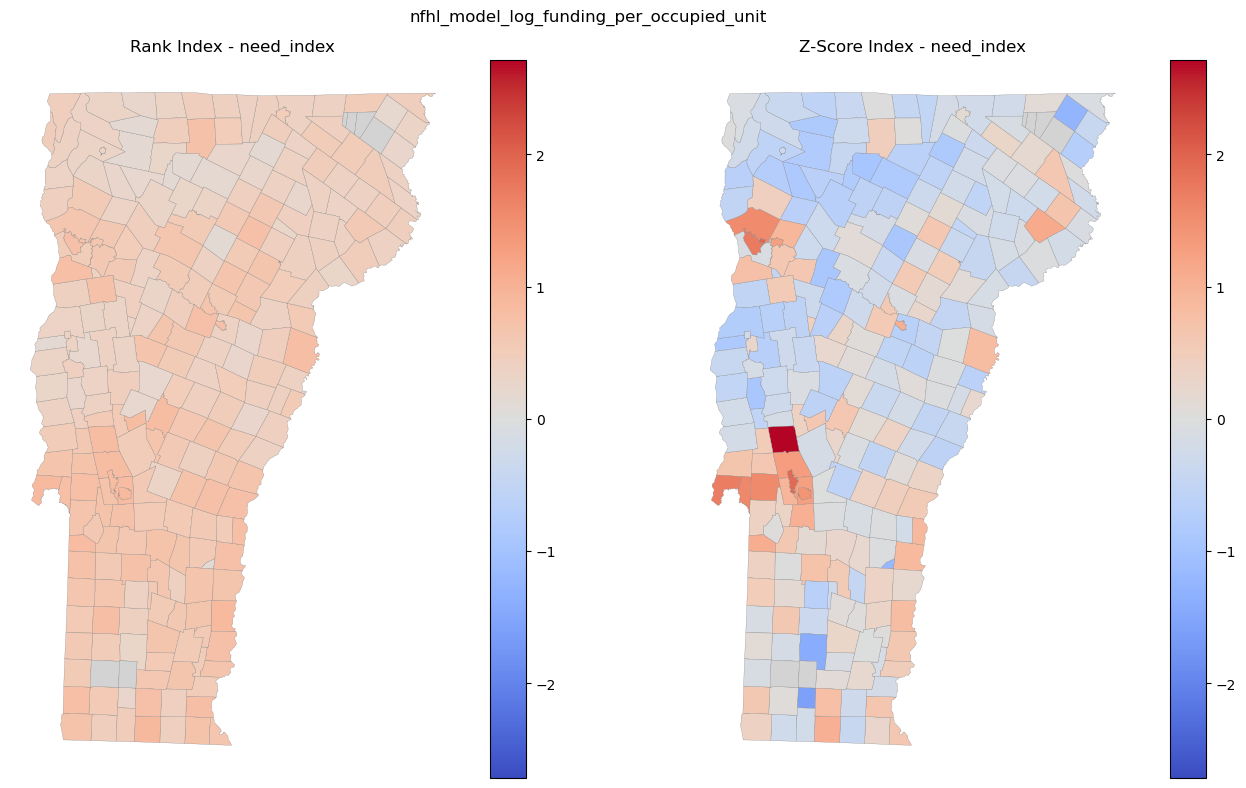


=== claims_only_log_funding_per_occupied_unit ===

Index Spearman correlation (z vs rank): 1.000


{'highest_need':             town_name  need_index
 118       Ludlow town       0.500
 19        Berlin town       0.498
 133     Moretown town       0.496
 254    Woodstock town       0.494
 43     Cavendish town       0.492
 239       Weston town       0.490
 132   Montpelier city       0.488
 32     Brookline town       0.486
 246   Wilmington town       0.484
 27   Bridgewater town       0.482,
 'lowest_need':            town_name  need_index
 0       Addison town       0.106
 1        Albany town       0.106
 2       Alburgh town       0.106
 5        Athens town       0.106
 6       Averill town       0.106
 8   Bakersfield town       0.106
 9     Baltimore town       0.106
 10      Barnard town       0.106
 15    Belvidere town       0.106
 17       Benson town       0.106}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
0,5000100325,Addison town,-0.196297,0.106,53.0,53.0,0.0
1,5001900475,Albany town,-0.196297,0.106,53.0,53.0,0.0
2,5001300860,Alburgh town,-0.196297,0.106,53.0,53.0,0.0
3,5002701300,Andover town,-0.085151,0.372,186.0,186.0,0.0
4,5000301450,Arlington town,-0.164953,0.318,159.0,159.0,0.0
5,5002501900,Athens town,-0.196297,0.106,53.0,53.0,0.0
6,5000902125,Averill town,-0.196297,0.106,53.0,53.0,0.0
7,5001102500,Bakersfield town,-0.196297,0.106,53.0,53.0,0.0
8,5002702575,Baltimore town,-0.196297,0.106,53.0,53.0,0.0
9,5002702725,Barnard town,-0.196297,0.106,53.0,53.0,0.0


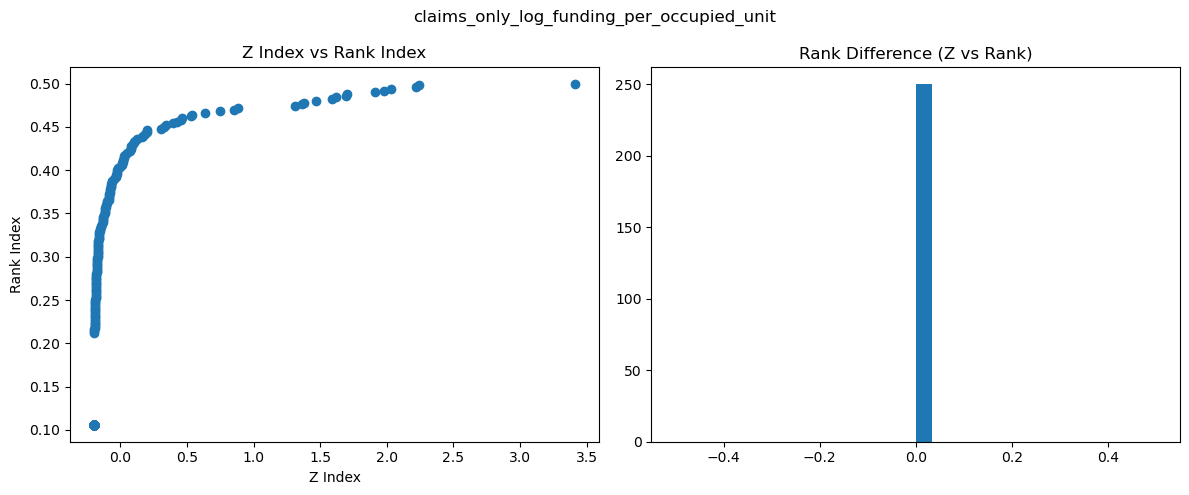

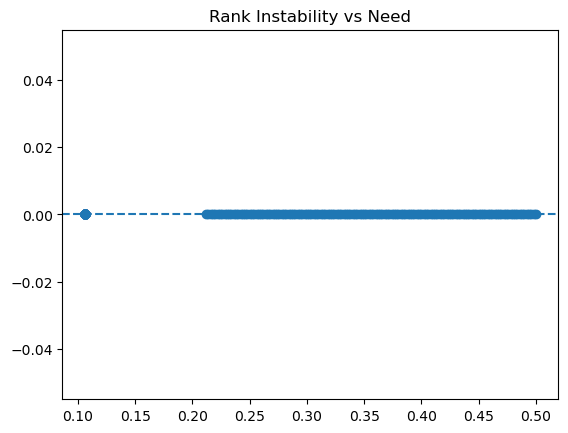

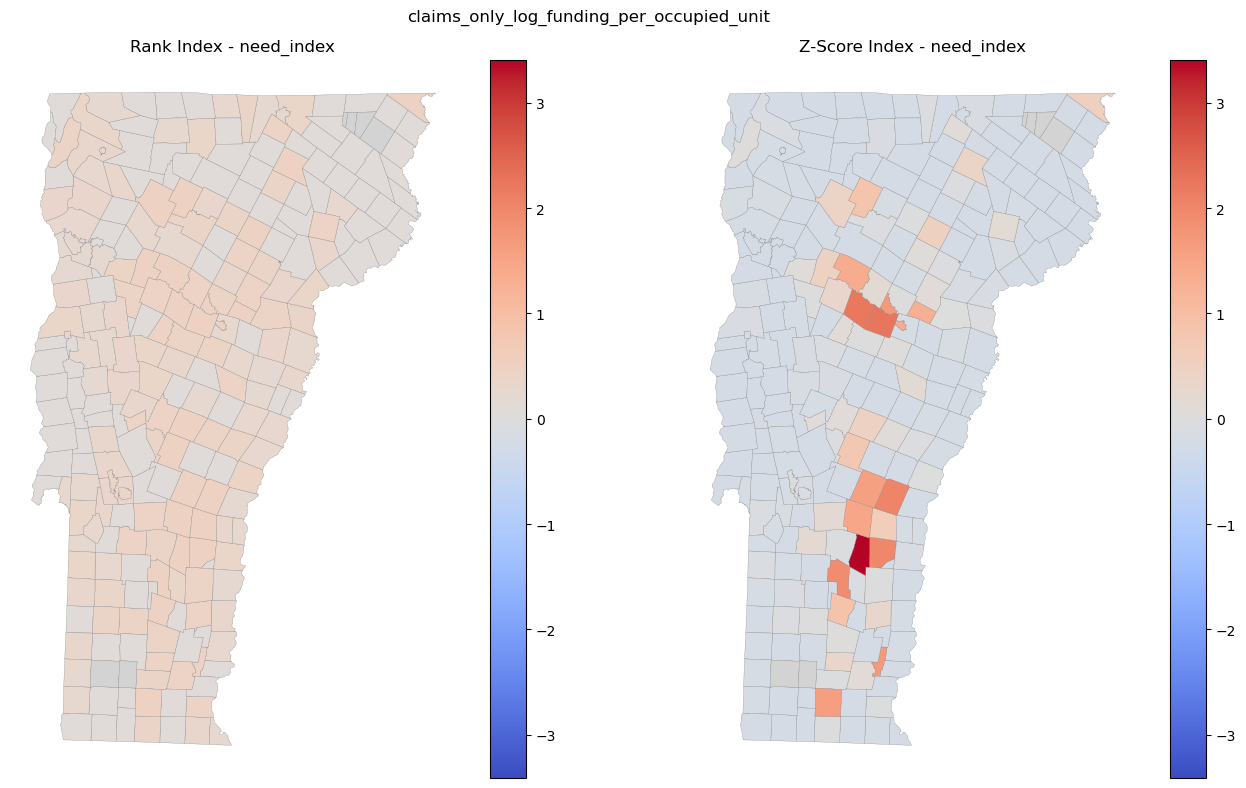


=== combined_log_funding_per_occupied_unit ===

Index Spearman correlation (z vs rank): 0.951


{'highest_need':            town_name  need_index
 174     Rutland city       0.882
 216     Victory town       0.847
 161     Proctor town       0.840
 175     Rutland town       0.836
 240   Weybridge town       0.831
 54     Coventry town       0.829
 232  West Haven town       0.828
 155   Pittsford town       0.814
 25      Brandon town       0.813
 112   Leicester town       0.809,
 'lowest_need':            town_name  need_index
 9     Baltimore town      0.0360
 201    Stratton town      0.0465
 66       Elmore town      0.0840
 193  St. George town      0.1040
 85   Grand Isle town      0.1310
 6       Averill town      0.1435
 153        Peru town      0.1590
 74      Fayston town      0.1730
 65         Eden town      0.1750
 13        Barre town      0.1890}

,GEOID,town_name,need_index_z,need_index_rank,rank_z,rank_rank,rank_diff
34,5000710300,Buels gore,0.047183,0.2645,149.0,31.0,118.0
82,5000929125,Granby town,0.724236,0.4960,231.0,121.0,110.0
181,5001164600,Sheldon town,0.502935,0.5520,215.0,148.0,67.0
168,5002360625,Roxbury town,-0.053962,0.3750,130.0,64.0,66.0
233,5002782000,Weston town,0.329439,0.5160,189.0,133.0,56.0
170,5000361000,Rupert town,0.364435,0.5420,199.0,144.5,54.5
70,5001124925,Fairfax town,0.356313,0.5400,197.0,143.0,54.0
80,5000128600,Goshen town,0.281538,0.5140,183.0,130.0,53.0
67,5000724400,Essex Junction city,1.909337,0.6760,246.0,198.0,48.0
85,5001930175,Greensboro town,0.200844,0.5290,177.0,138.0,39.0


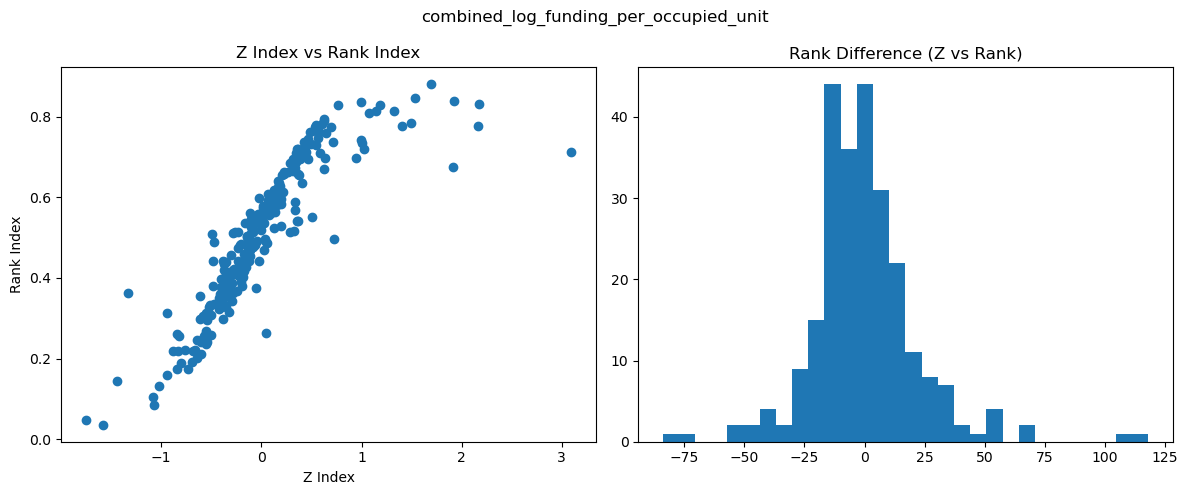

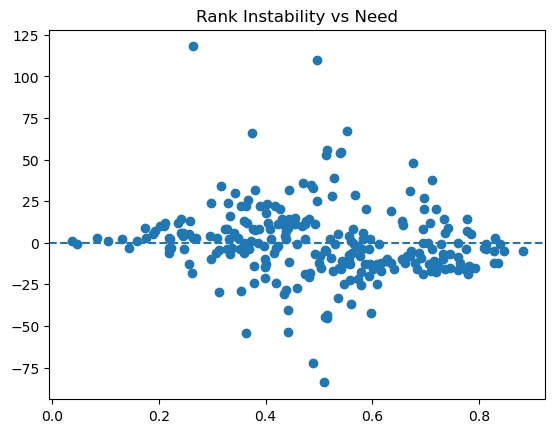

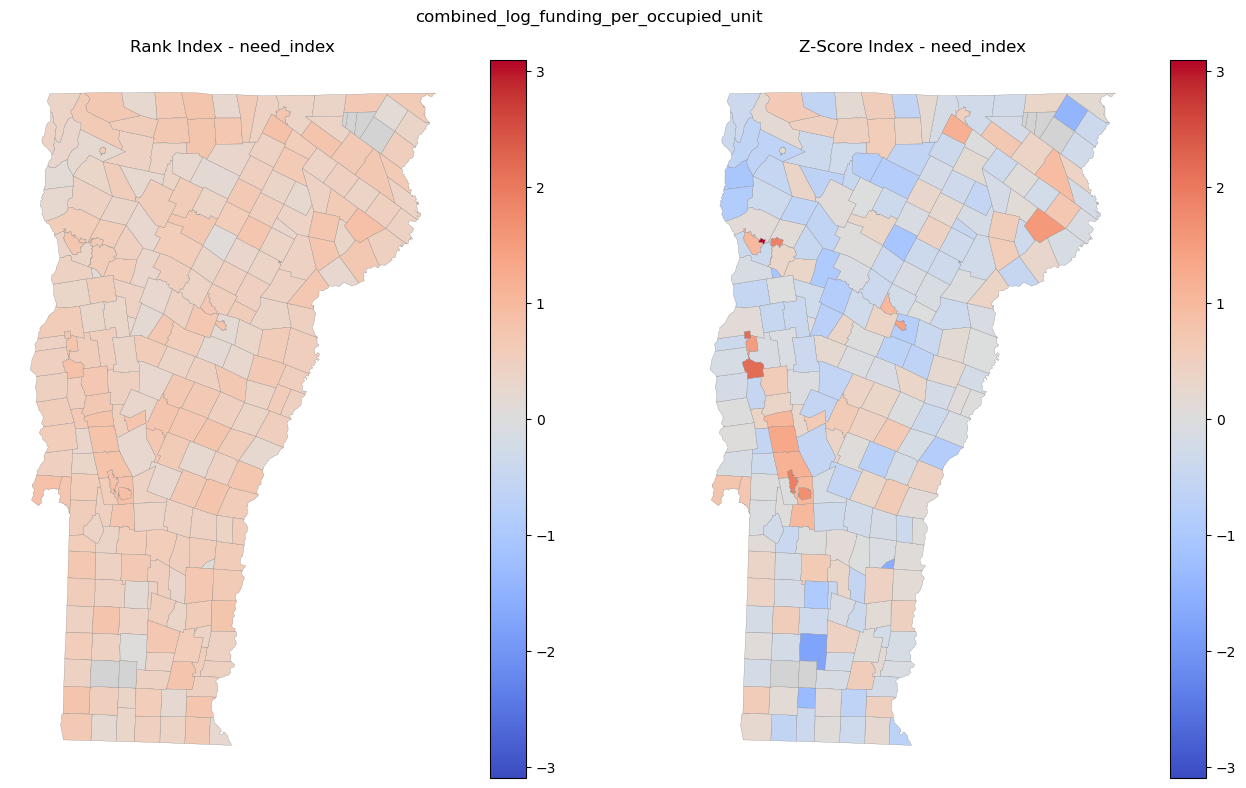


=== SUMMARY ===


,model,index_spearman_z_vs_rank,mean_rank_diff,max_rank_diff,pct_rank_diff_gtr_50,ols_n,ols_r2,logit_auc
0,baseline_exposure_log_funding_per_capita,1.000000,0.000,0.0,0.000,120,0.011020,0.610000
5,claims_only_log_funding_per_capita,1.000000,0.000,0.0,0.000,120,0.069120,0.783205
7,baseline_exposure_log_funding_per_occupied_unit,1.000000,0.000,0.0,0.000,120,0.013115,0.610000
12,claims_only_log_funding_per_occupied_unit,1.000000,0.000,0.0,0.000,120,0.063555,0.783205
3,expanded_model_log_funding_per_capita,0.969257,12.832,93.0,0.024,120,0.112761,0.667115
10,expanded_model_log_funding_per_occupied_unit,0.969257,12.832,93.0,0.024,120,0.103387,0.667115
2,core_model_log_funding_per_capita,0.958757,14.840,101.0,0.028,120,0.109632,0.631603
9,core_model_log_funding_per_occupied_unit,0.958757,14.840,101.0,0.028,120,0.098325,0.631603
1,baseline_vulnerability_log_funding_per_capita,0.958185,14.008,118.0,0.032,120,0.108434,0.627500
8,baseline_vulnerability_log_funding_per_occupie...,0.958185,14.008,118.0,0.032,120,0.097817,0.627500


In [10]:
# results, summary = run_model_suite(df, gdf, model_specs)

expanded_specs = {}
for funding_var in ["log_funding_per_capita", "log_funding_per_occupied_unit"]:
    for name, spec in model_specs.items():
        new_name = f"{name}_{funding_var}"
        expanded_specs[new_name] = {**spec, "funding_var": funding_var}

results, summary = run_model_suite(df, gdf, expanded_specs)